# PSD estimator bias-variance comparison

Empirical MSE / bias / variance of the raw estimators (Welch, lag-window,
multitaper) against their PSDebias fits, the fixed-mesh Dquad baseline
(debias arm) and wavelet thresholding (smoothing arm), on AR(4) and Matérn
processes. All statistics are computed in the log-spectrum domain against the
closed-form truth.

Inputs are the caches written by `scripts/generate_realisations.py`
(`debias` and `smooth` arms) and `scripts/wavelet_thresholding.py`.

In [16]:
import os

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

from psdebias import ar_spectrum, matern_spectrum

try:
    import scienceplots  # noqa: F401
    plt.style.use(['science', 'ieee'])
except ImportError:
    pass

In [17]:
BASE = '../scripts/realisations'  # output of generate_realisations.py
FIGS = '../figs'

MS_WELCH = [2 ** i for i in range(3, 7)]  # Welch: segment counts
NW_SMOOTH = [3, 4, 5, 6]                  # lag-window / multitaper NW, smoothing arm
NW_DEBIAS = [3, 4, 6, 8]                  # lag-window / multitaper NW, debias arm
N_QUAD = {'unbiased': 2 ** 13, 'debiasing': 2 ** 11}  # quad-arm series lengths

AR4_POLY = np.array([1.0, -2.7607, 3.8106, -2.6535, 0.9238])
MATERN_ALPHA = 1.5
MATERN_LAMBDA = 0.1

## Shared helpers

One loader / stats / print / plot pipeline driven by a per-method config.
Adaptive CSVs hold `[E[#knots]] + mean_S(f) + std_S(f)` in linear scale (both
arms — smooth-mode draws are exponentiated inside the sampler), so every
stream is logged here before comparison.

In [18]:
def truth_spectrum(freqs, signal):
    if signal == 'ar4':
        return ar_spectrum(freqs, AR4_POLY, sd=1.0)
    return matern_spectrum(freqs, eta=1.0, alpha=MATERN_ALPHA, lmbda=MATERN_LAMBDA)


def load_results(cfg, ms, base_dir, signal):
    """Load one method's caches: raw estimates, adaptive CSVs, and (when the
    generating arm produced them) Dquad / wavelet stacks."""
    sim_dir = f"{base_dir}/{cfg['sim_subdir']}"

    value = np.array([np.load(f"{sim_dir}/{cfg['value'].format(m=m)}") for m in ms])
    adapt_raw = np.array([
        np.genfromtxt(f"{sim_dir}/{cfg['adapt'].format(m=m)}", delimiter=',')
        for m in ms
    ])

    n_freq = value.shape[-1]
    freqs = sp.fft.rfftfreq(2 * n_freq + 2, d=1.0)[1:-1]
    adapt = adapt_raw[..., 1:n_freq + 1]  # drop E[#knots]; ignore the std block

    try:
        dquad = [np.load(f"{sim_dir}/{cfg['dquad'].format(m=m)}") for m in ms]
    except FileNotFoundError:
        dquad = None

    try:
        wavelet = [np.load(f"{sim_dir}/{cfg['wavelet'].format(m=m)}") for m in ms]
    except FileNotFoundError:
        wavelet = None

    return {
        'value': value, 'adapt': adapt, 'dquad': dquad, 'wavelet': wavelet,
        'expected_knots': adapt_raw[..., 0], 'Truth': truth_spectrum(freqs, signal),
    }


def _stream_stats(stream, log_truth):
    """Per-setting list of (n_realisations, 3) arrays of [MSE, Bias, Var].

    Kept ragged: the Dquad stacks can have fewer (even zero) surviving
    realisations per setting, unlike the always-full value/adapt/wavelet."""
    out = []
    for sim in stream:
        vals = np.log(np.asarray(sim)).reshape(-1, log_truth.size)
        diff = vals - log_truth
        mse = np.mean(diff ** 2, axis=-1)
        bias = np.mean(diff, axis=-1)
        out.append(np.stack([mse, bias, mse - bias ** 2], axis=-1))
    return out


def compute_stats(results):
    log_truth = np.log(results['Truth'])
    stats = {}
    for key in ('value', 'adapt', 'dquad', 'wavelet'):
        stream = results[key]
        stats[key] = _stream_stats(stream, log_truth) if stream is not None else None
    return stats


STREAM_LABELS = {'adapt': 'PSDebias', 'dquad': 'Dquad', 'wavelet': 'Wavelet Thresholding'}


def _safe_mean(x):
    return np.mean(x) if len(x) else np.nan


def _safe_std(x):
    return np.std(x) if len(x) else np.nan


def _mean_band_per_setting(stream_stats, col):
    means = np.array([_safe_mean(s[:, col]) for s in stream_stats])
    stds = np.array([_safe_std(s[:, col]) for s in stream_stats])
    return means, means - stds, means + stds


def print_ratios(stats, ms_labels):
    """Each stream's MSE / Bias^2 / Var relative to the raw estimator."""
    base_mse = np.array([_safe_mean(s[:, 0]) for s in stats['value']])
    base_bias2 = np.array([_safe_mean(s[:, 1] ** 2) for s in stats['value']])
    base_var = np.array([_safe_mean(s[:, 2]) for s in stats['value']])

    for key, label in STREAM_LABELS.items():
        stream = stats.get(key)
        if stream is None:
            continue
        mse = np.array([_safe_mean(s[:, 0]) for s in stream])
        bias2 = np.array([_safe_mean(s[:, 1] ** 2) for s in stream])
        var = np.array([_safe_mean(s[:, 2]) for s in stream])
        print(f"{label}:")
        for i, m in enumerate(ms_labels):
            print(f"  {m}: MSE: {mse[i] / base_mse[i]:.2f}, "
                  f"Bias^2: {bias2[i] / base_bias2[i]:.2f}, Var: {var[i] / base_var[i]:.2f}")


def plot_results(ms, stats, label, xlabel, xticklabels=None, fig_title=''):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    for col, title in enumerate(['MSE', 'Bias', 'Var']):
        mean_v, lower_v, upper_v = _mean_band_per_setting(stats['value'], col)
        mean_a, lower_a, upper_a = _mean_band_per_setting(stats['adapt'], col)
        ax[col].plot(ms, mean_v, label=label, linestyle='dashed')
        ax[col].fill_between(ms, lower_v, upper_v, alpha=0.2)
        ax[col].plot(ms, mean_a, label='PSDebias')
        ax[col].fill_between(ms, lower_a, upper_a, alpha=0.2)

        for key in ('dquad', 'wavelet'):
            stream = stats.get(key)
            if stream is None:
                continue
            mean_s, lower_s, upper_s = _mean_band_per_setting(stream, col)
            ax[col].plot(ms, mean_s, label=STREAM_LABELS[key])
            ax[col].fill_between(ms, lower_s, upper_s, alpha=0.2)

        ax[col].legend()
        ax[col].set_title(title)
        ax[col].set_xticks(ms)
        ax[col].set_xlabel(xlabel)
        if xticklabels is not None:
            ax[col].set_xticklabels(xticklabels)

    fig.suptitle(fig_title)
    return fig, ax

## Method configurations

File layout and x-axis per estimator. Lag-window settings are keyed by NW on
disk but displayed by lag truncation $\tau = N/\mathrm{NW}$ (hence the
reversed file list, so the display axis ascends).

In [19]:
METHODS = {
    'Welch': {
        'slug': 'welch', 'sim_subdir': 'welch_sim',
        'value': 'welch/{m}.npy', 'adapt': 'adapt_welch/{m}.csv',
        'dquad': 'dwelch/{m}.npy', 'wavelet': 'welch_wavelet/{m}.npy',
        'xlabel': 'M',
        'xticklabels': [fr'$2^{{{int(np.log2(m))}}}$' for m in MS_WELCH],
        'file_ms': {'unbiased': MS_WELCH, 'debiasing': MS_WELCH},
        'display_ms': {'unbiased': MS_WELCH, 'debiasing': MS_WELCH},
    },
    'Lag-Window': {
        'slug': 'lag', 'sim_subdir': 'quad_sim',
        'value': 'lag-window/NW{m}.npy', 'adapt': 'adapt_lag/NW{m}.csv',
        'dquad': 'dlag/NW{m}.npy', 'wavelet': 'lag_wavelet/{m}.npy',
        'xlabel': r'$\tau$', 'xticklabels': None,
        'file_ms': {'unbiased': NW_SMOOTH[::-1], 'debiasing': NW_DEBIAS[::-1]},
        'display_ms': {
            arm: [N_QUAD[arm] // nw for nw in nws]
            for arm, nws in {'unbiased': NW_SMOOTH[::-1],
                             'debiasing': NW_DEBIAS[::-1]}.items()
        },
    },
    'Multitaper': {
        'slug': 'multi', 'sim_subdir': 'quad_sim',
        'value': 'multitaper/NW{m}.npy', 'adapt': 'adapt_multi/NW{m}.csv',
        'dquad': 'dmulti/NW{m}.npy', 'wavelet': 'multi_wavelet/{m}.npy',
        'xlabel': 'NW', 'xticklabels': None,
        'file_ms': {'unbiased': NW_SMOOTH, 'debiasing': NW_DEBIAS},
        'display_ms': {'unbiased': NW_SMOOTH, 'debiasing': NW_DEBIAS},
    },
}

ARMS = {'unbiased': 'unbias', 'debiasing': 'bias'}  # dir suffix -> figure slug

SIGNALS = {
    'ar4': {'slug': 'ar4', 'title': 'AR4'},
    'matern': {'slug': 'mat', 'title': 'Matérn'},
}

## Run all comparisons

Every (estimator × arm × signal) combination; skips arms whose realisations
have not been generated yet.

=== Welch / AR4 / unbiased ===
PSDebias:
  8: MSE: 0.08, Bias^2: 0.97, Var: 0.05
  16: MSE: 0.07, Bias^2: 0.97, Var: 0.07
  32: MSE: 0.09, Bias^2: 0.97, Var: 0.08
  64: MSE: 0.12, Bias^2: 0.99, Var: 0.12
Wavelet Thresholding:
  8: MSE: 0.37, Bias^2: 1.03, Var: 0.35
  16: MSE: 0.34, Bias^2: 1.11, Var: 0.34
  32: MSE: 0.33, Bias^2: 1.11, Var: 0.32
  64: MSE: 0.37, Bias^2: 1.10, Var: 0.37


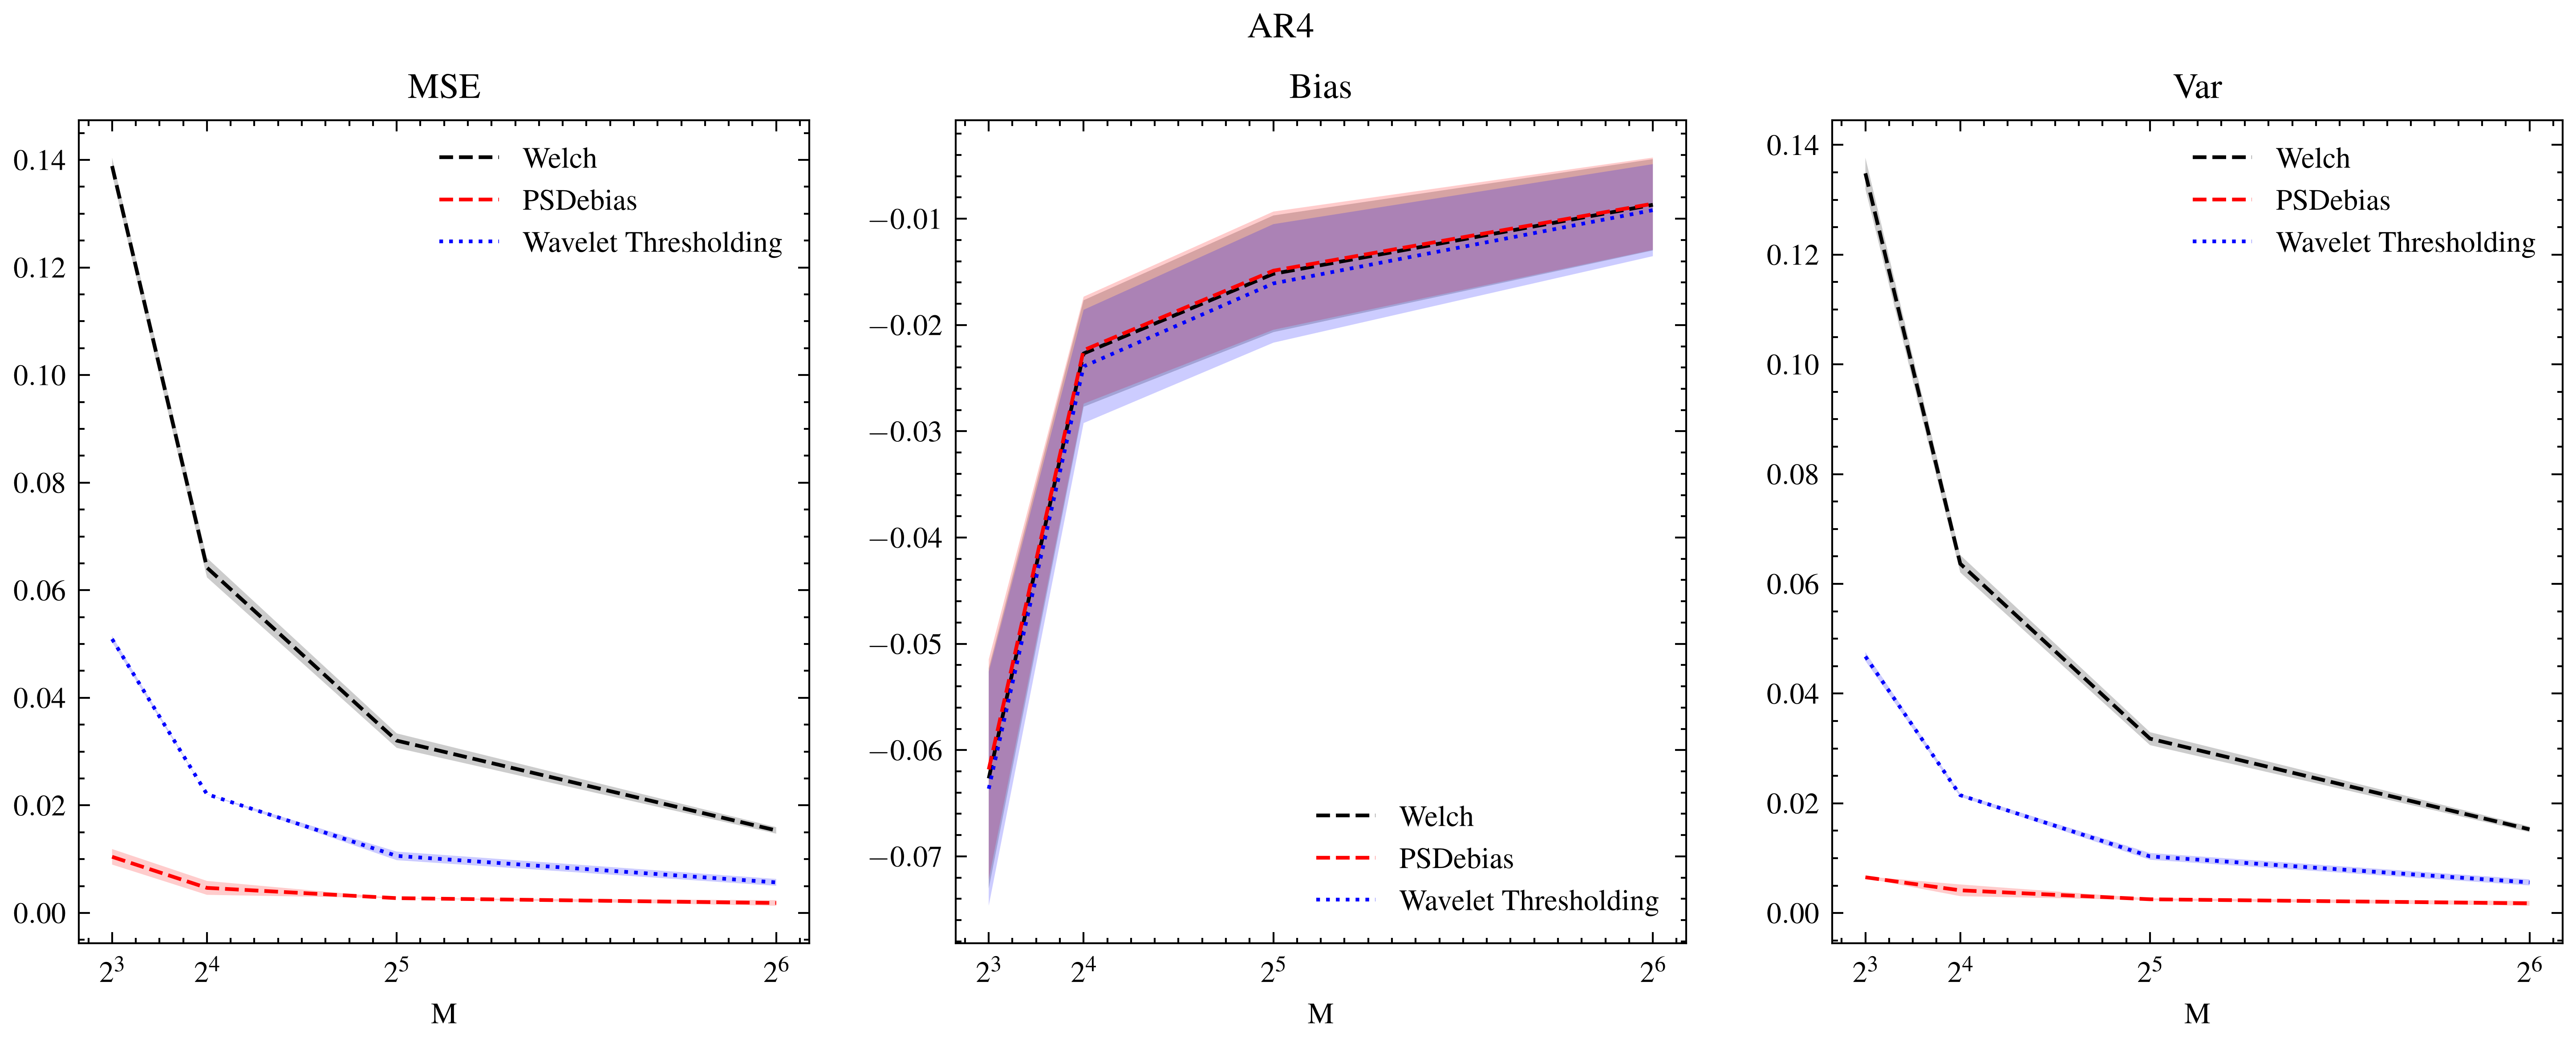

=== Welch / Matérn / unbiased ===
PSDebias:
  8: MSE: 0.26, Bias^2: 1.01, Var: 0.24
  16: MSE: 0.46, Bias^2: 1.00, Var: 0.39
  32: MSE: 0.65, Bias^2: 1.00, Var: 0.57
  64: MSE: 0.79, Bias^2: 1.00, Var: 0.71
Wavelet Thresholding:
  8: MSE: 0.44, Bias^2: 1.18, Var: 0.42
  16: MSE: 0.58, Bias^2: 1.09, Var: 0.51
  32: MSE: 0.74, Bias^2: 1.06, Var: 0.66
  64: MSE: 0.84, Bias^2: 1.05, Var: 0.76


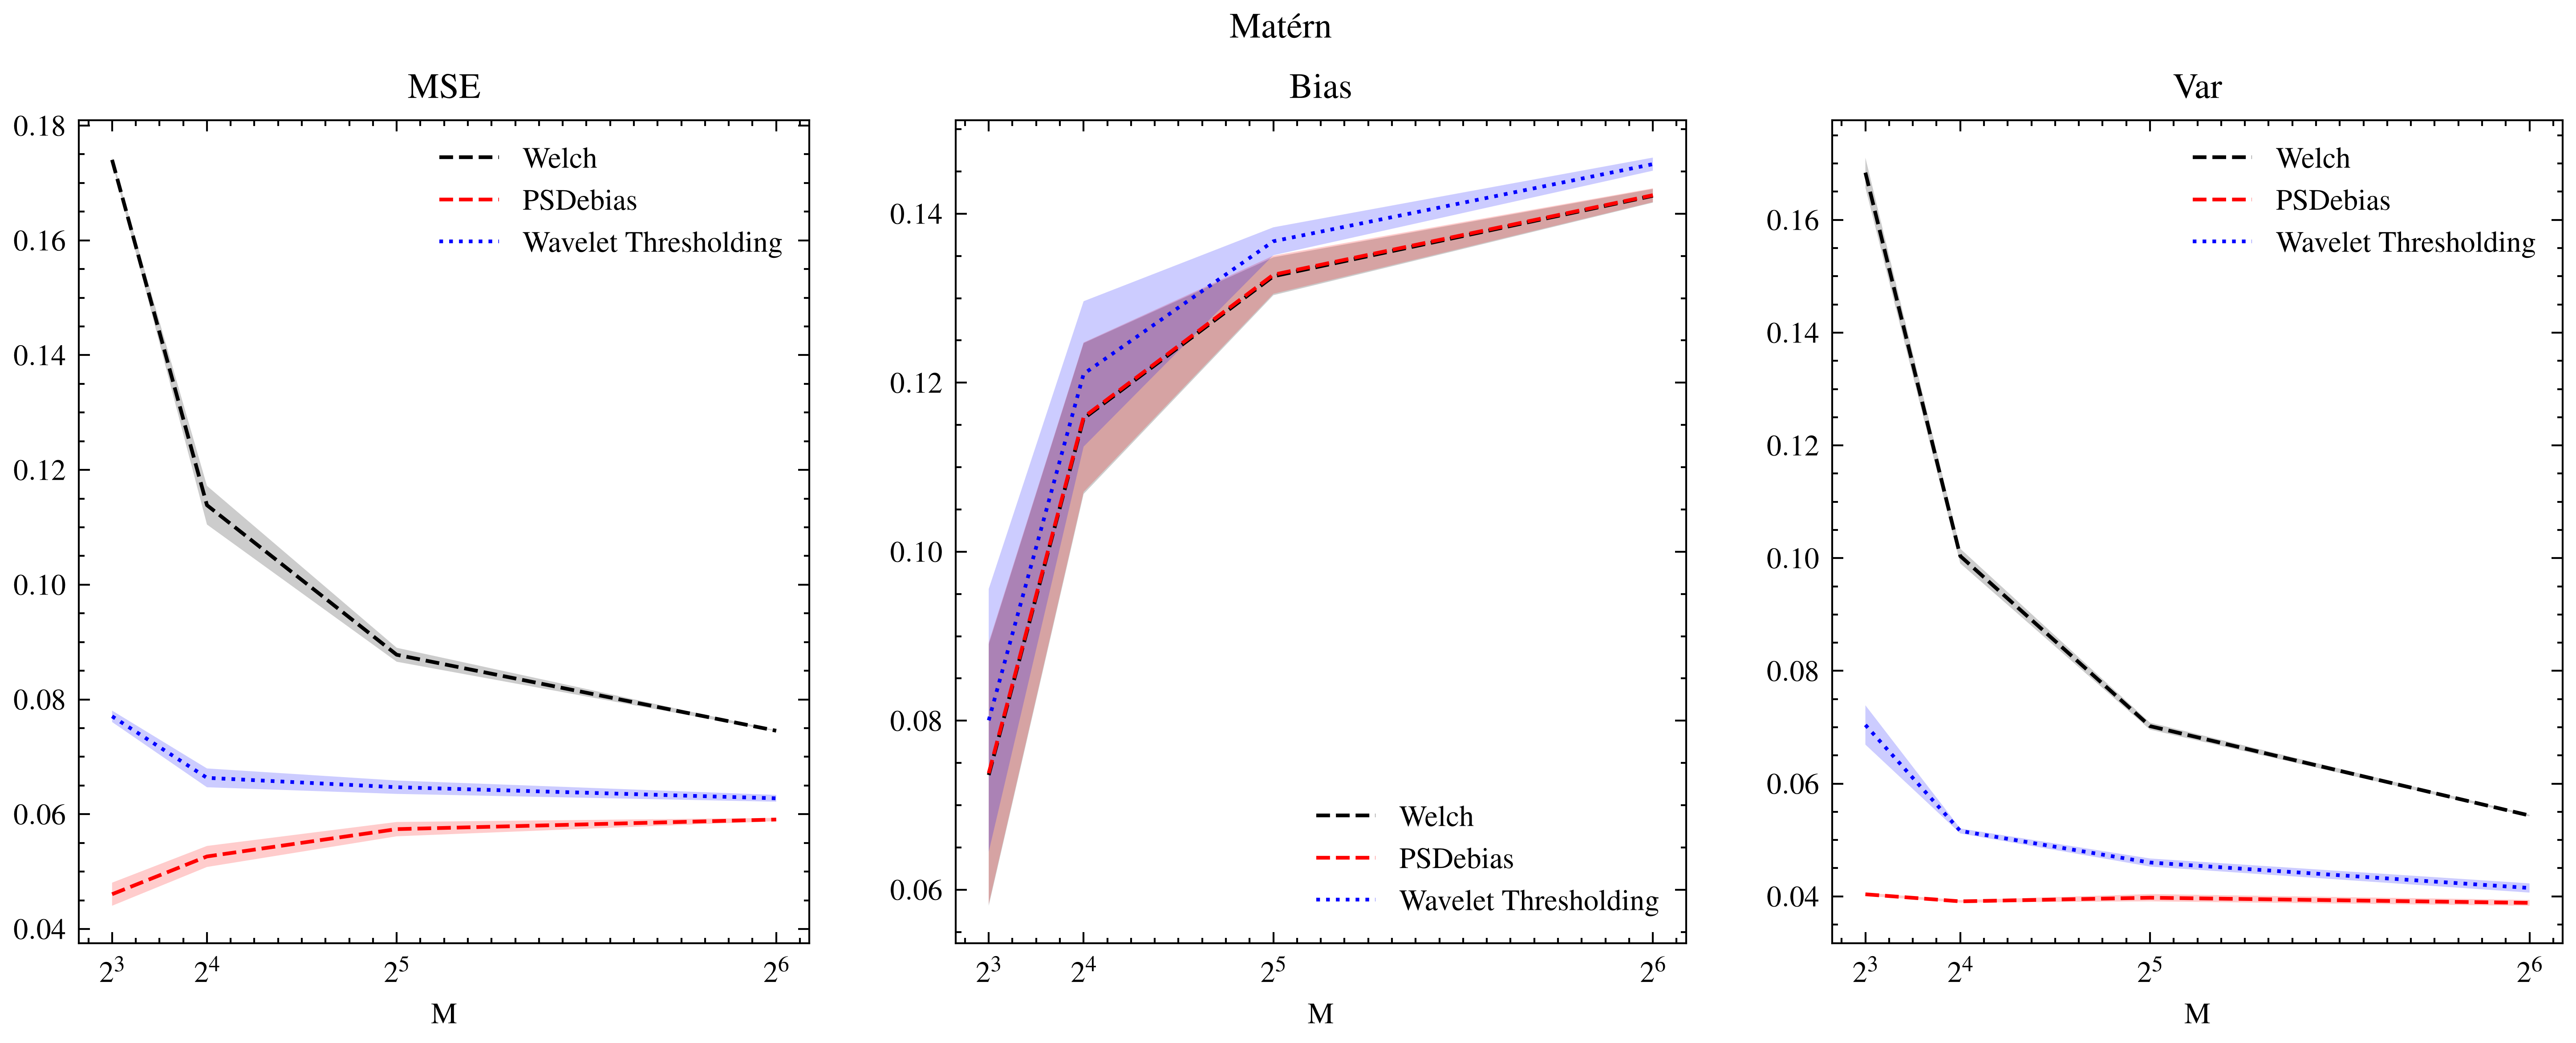

=== Welch / AR4 / debiasing ===
PSDebias:
  8: MSE: 0.80, Bias^2: 0.69, Var: 0.95
  16: MSE: 0.03, Bias^2: 0.01, Var: 0.05
  32: MSE: 0.09, Bias^2: 0.06, Var: 0.12
  64: MSE: 0.10, Bias^2: 0.07, Var: 0.13
Dquad:
  8: MSE: 0.78, Bias^2: 0.68, Var: 0.93
  16: MSE: nan, Bias^2: nan, Var: nan
  32: MSE: 0.04, Bias^2: 0.01, Var: 0.09
  64: MSE: 0.10, Bias^2: 0.07, Var: 0.14


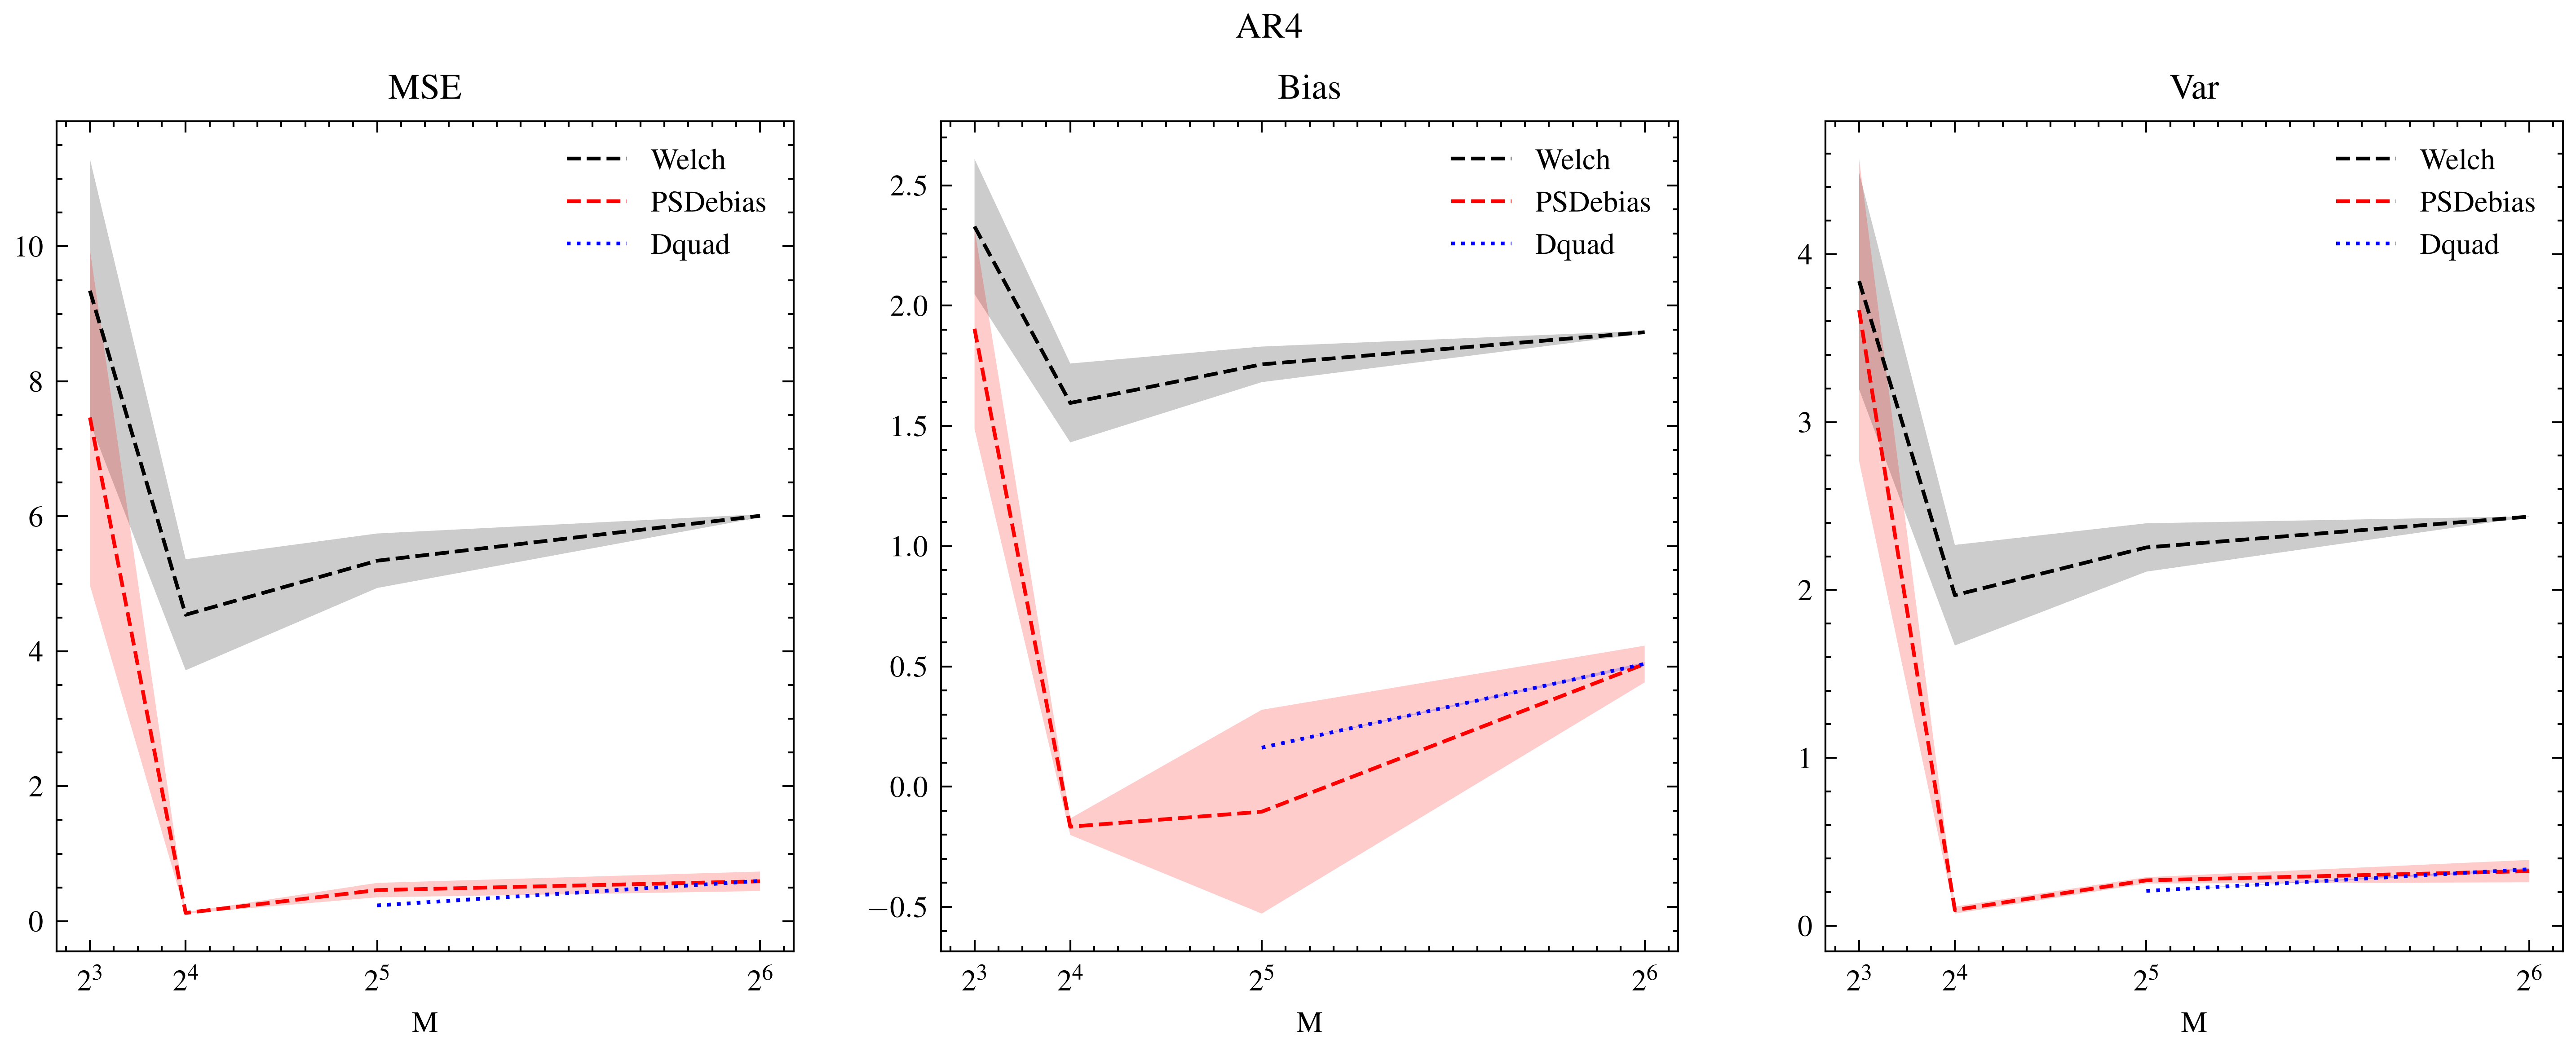

=== Welch / Matérn / debiasing ===
PSDebias:
  8: MSE: 0.33, Bias^2: 0.51, Var: 0.29
  16: MSE: 0.27, Bias^2: 0.06, Var: 0.34
  32: MSE: 0.32, Bias^2: 0.12, Var: 0.45
  64: MSE: 0.41, Bias^2: 0.26, Var: 0.54
Dquad:
  8: MSE: 0.58, Bias^2: 0.21, Var: 0.67
  16: MSE: 0.42, Bias^2: 0.05, Var: 0.54
  32: MSE: 0.39, Bias^2: 0.15, Var: 0.54
  64: MSE: 0.44, Bias^2: 0.28, Var: 0.58


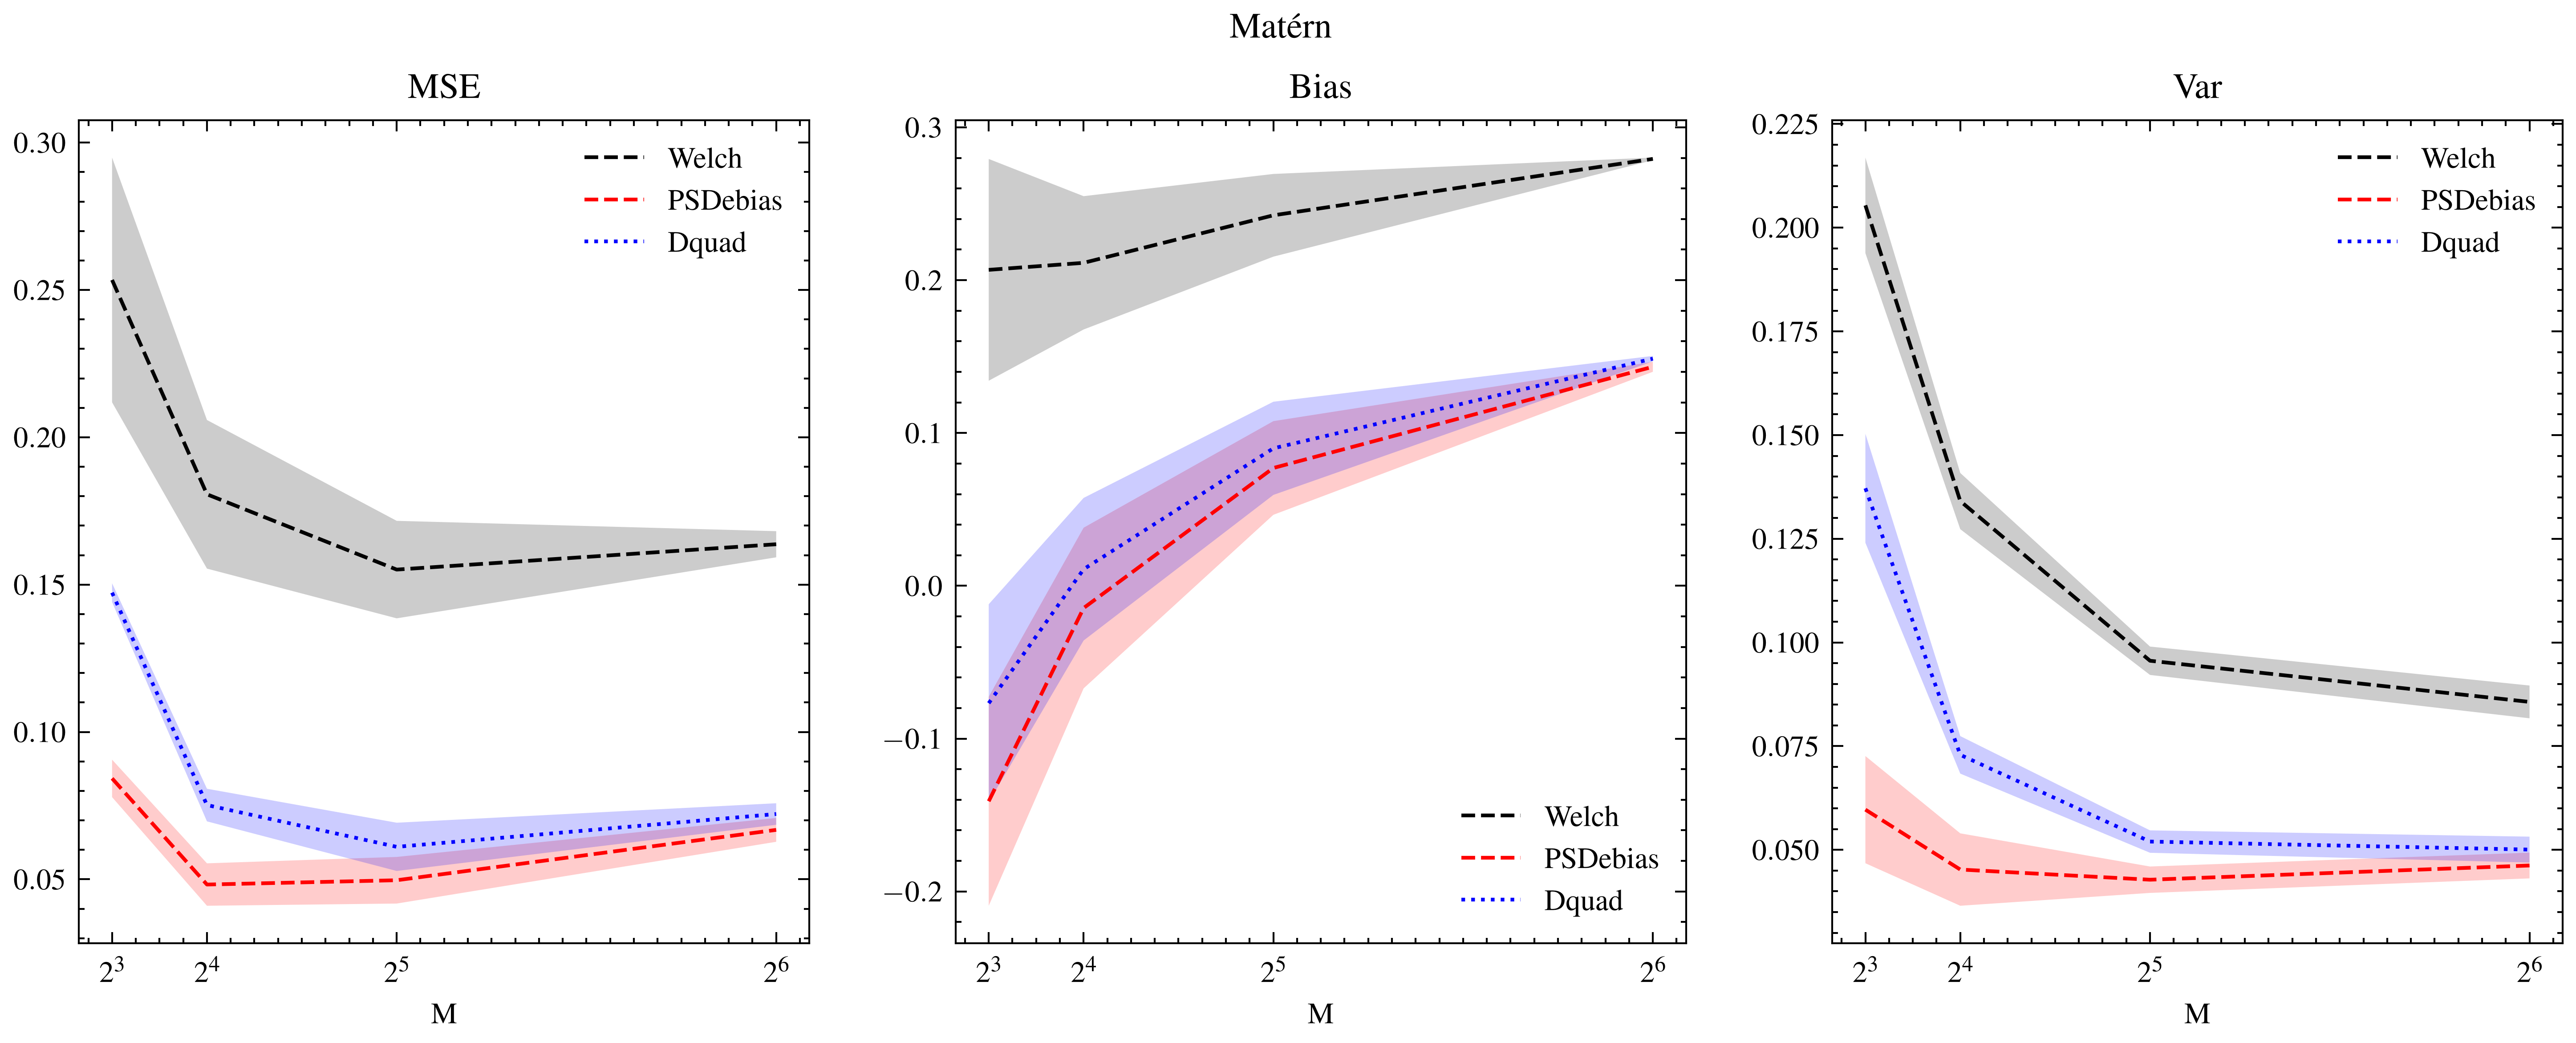

=== Lag-Window / AR4 / unbiased ===
PSDebias:
  1365: MSE: 0.98, Bias^2: 1.00, Var: 0.96
  1638: MSE: 0.97, Bias^2: 1.00, Var: 0.95
  2048: MSE: 0.96, Bias^2: 1.00, Var: 0.93
  2730: MSE: 0.95, Bias^2: 1.00, Var: 0.90
Wavelet Thresholding:
  1365: MSE: 0.97, Bias^2: 1.00, Var: 0.95
  1638: MSE: 0.97, Bias^2: 1.00, Var: 0.94
  2048: MSE: 0.96, Bias^2: 1.00, Var: 0.92
  2730: MSE: 0.94, Bias^2: 1.00, Var: 0.90


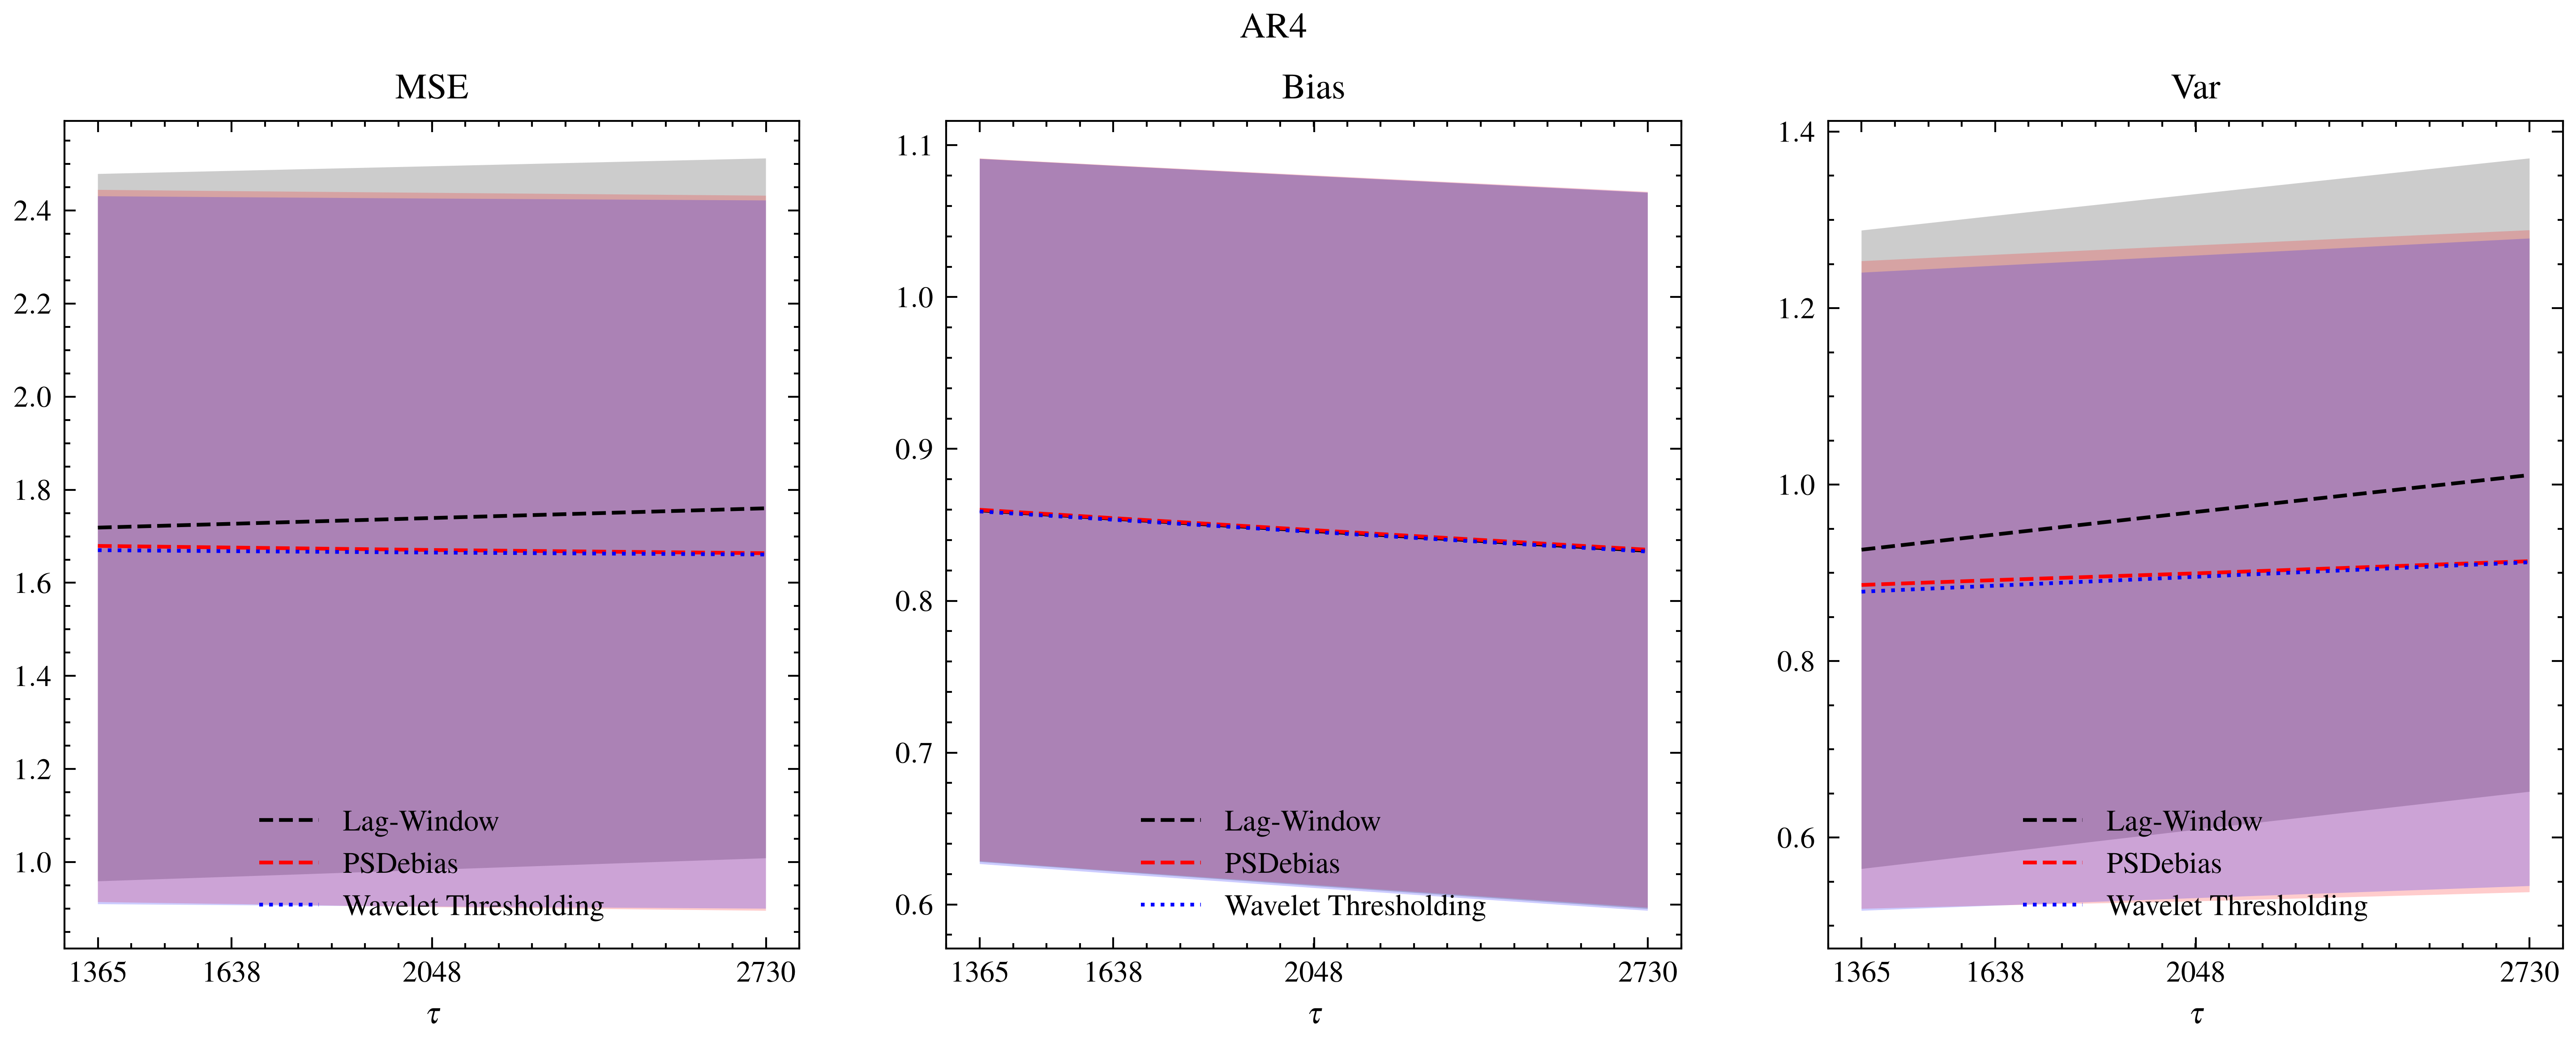

=== Lag-Window / Matérn / unbiased ===
PSDebias:
  1365: MSE: 0.55, Bias^2: 1.02, Var: 0.50
  1638: MSE: 0.48, Bias^2: 1.02, Var: 0.43
  2048: MSE: 0.38, Bias^2: 1.02, Var: 0.34
  2730: MSE: 0.28, Bias^2: 1.02, Var: 0.26
Wavelet Thresholding:
  1365: MSE: 0.46, Bias^2: 1.08, Var: 0.39
  1638: MSE: 0.40, Bias^2: 1.10, Var: 0.34
  2048: MSE: 0.33, Bias^2: 1.13, Var: 0.28
  2730: MSE: 0.25, Bias^2: 1.20, Var: 0.23


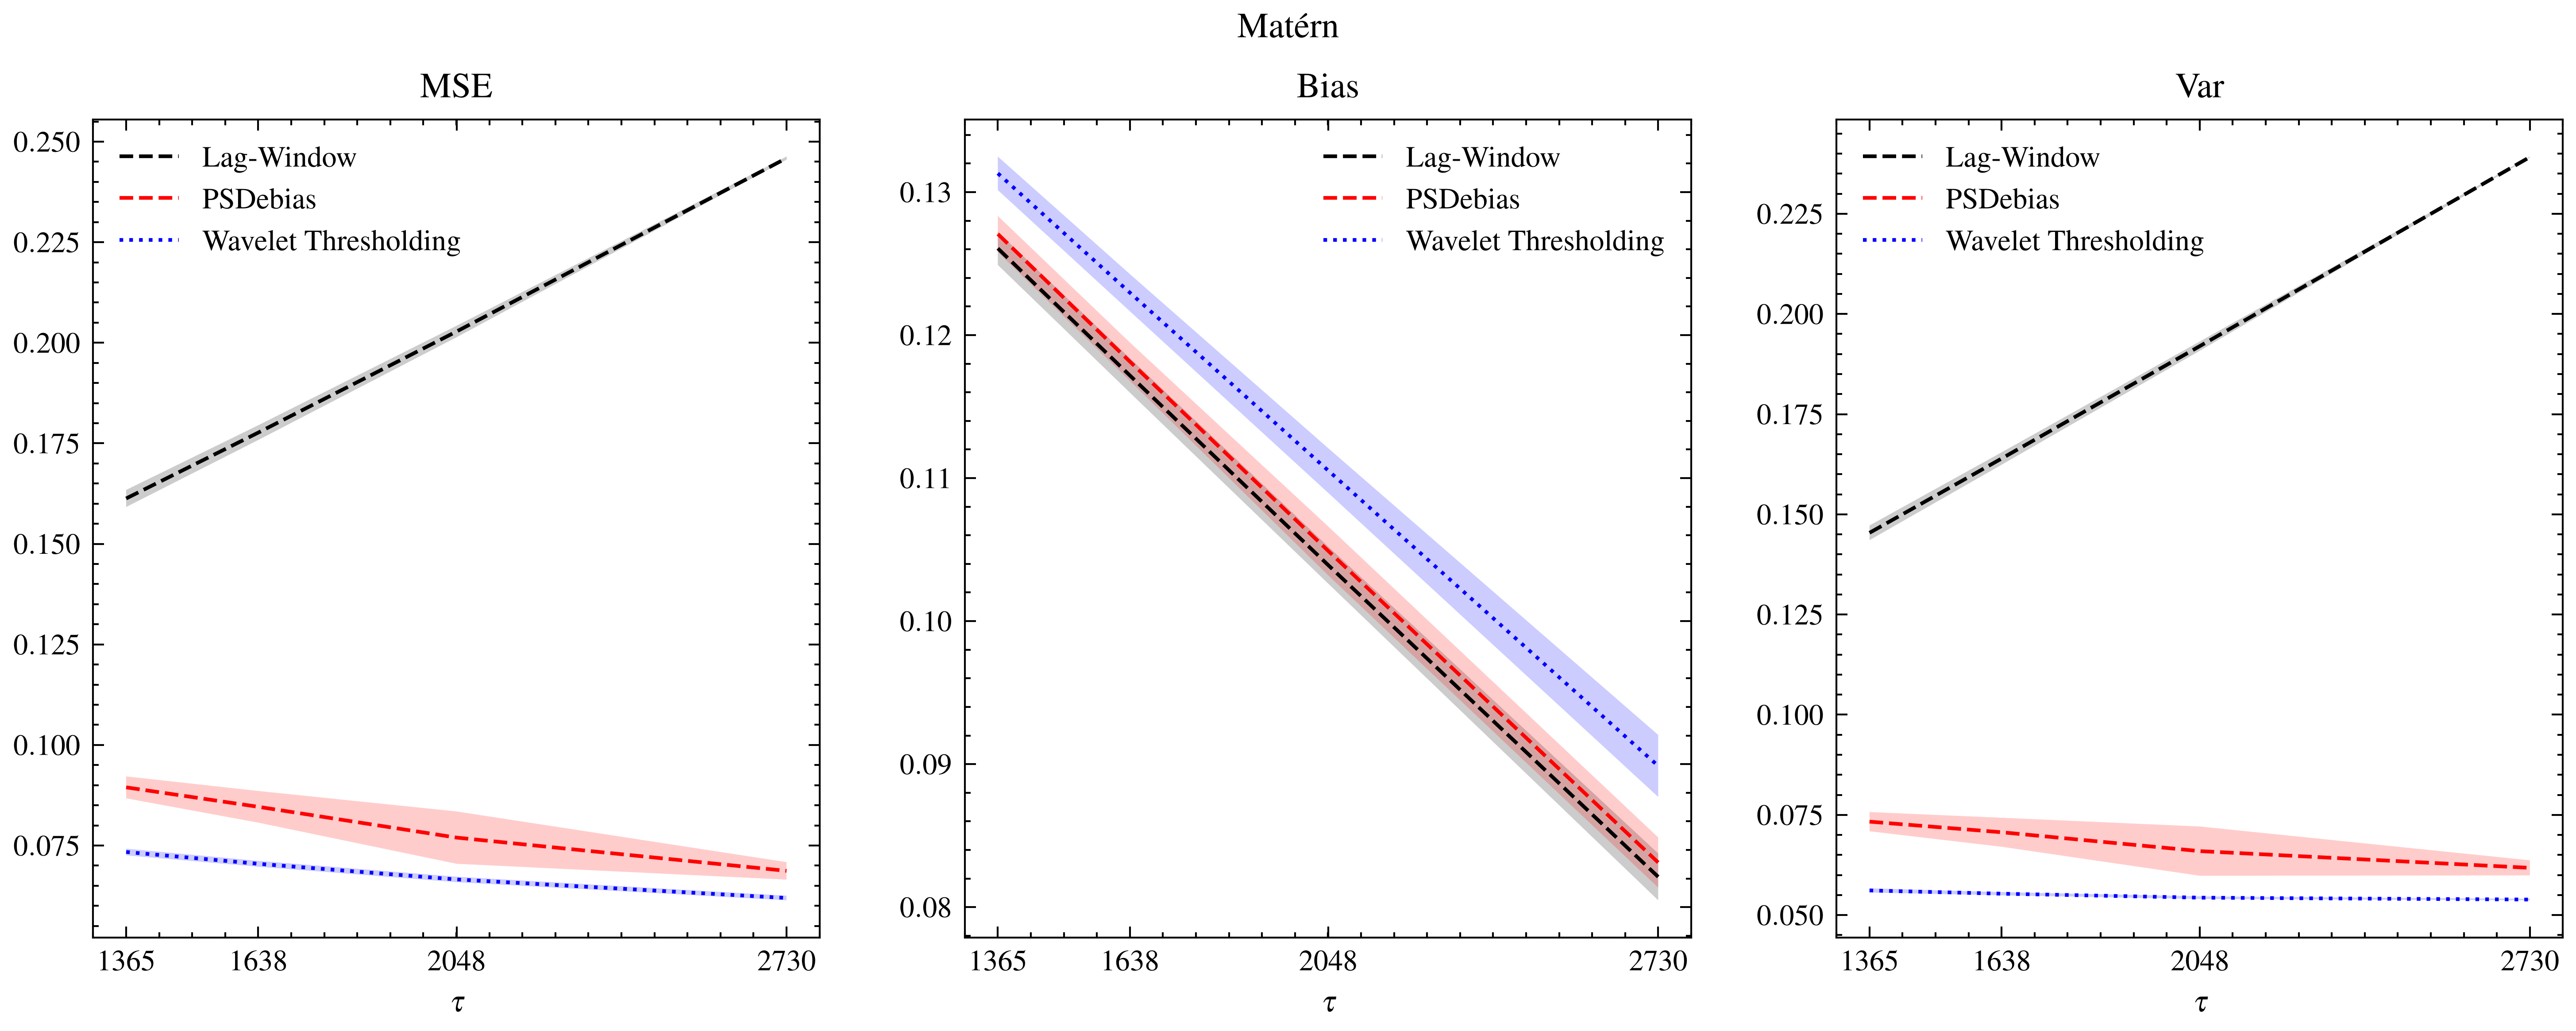

=== Lag-Window / AR4 / debiasing ===
PSDebias:
  256: MSE: 0.04, Bias^2: 0.03, Var: 0.07
  341: MSE: 0.25, Bias^2: 0.20, Var: 0.35
  512: MSE: 0.18, Bias^2: 0.11, Var: 0.30
  682: MSE: 0.54, Bias^2: 0.44, Var: 0.71
Dquad:
  256: MSE: nan, Bias^2: nan, Var: nan
  341: MSE: 0.45, Bias^2: 0.35, Var: 0.66
  512: MSE: 0.26, Bias^2: 0.17, Var: 0.41
  682: MSE: 0.55, Bias^2: 0.45, Var: 0.73


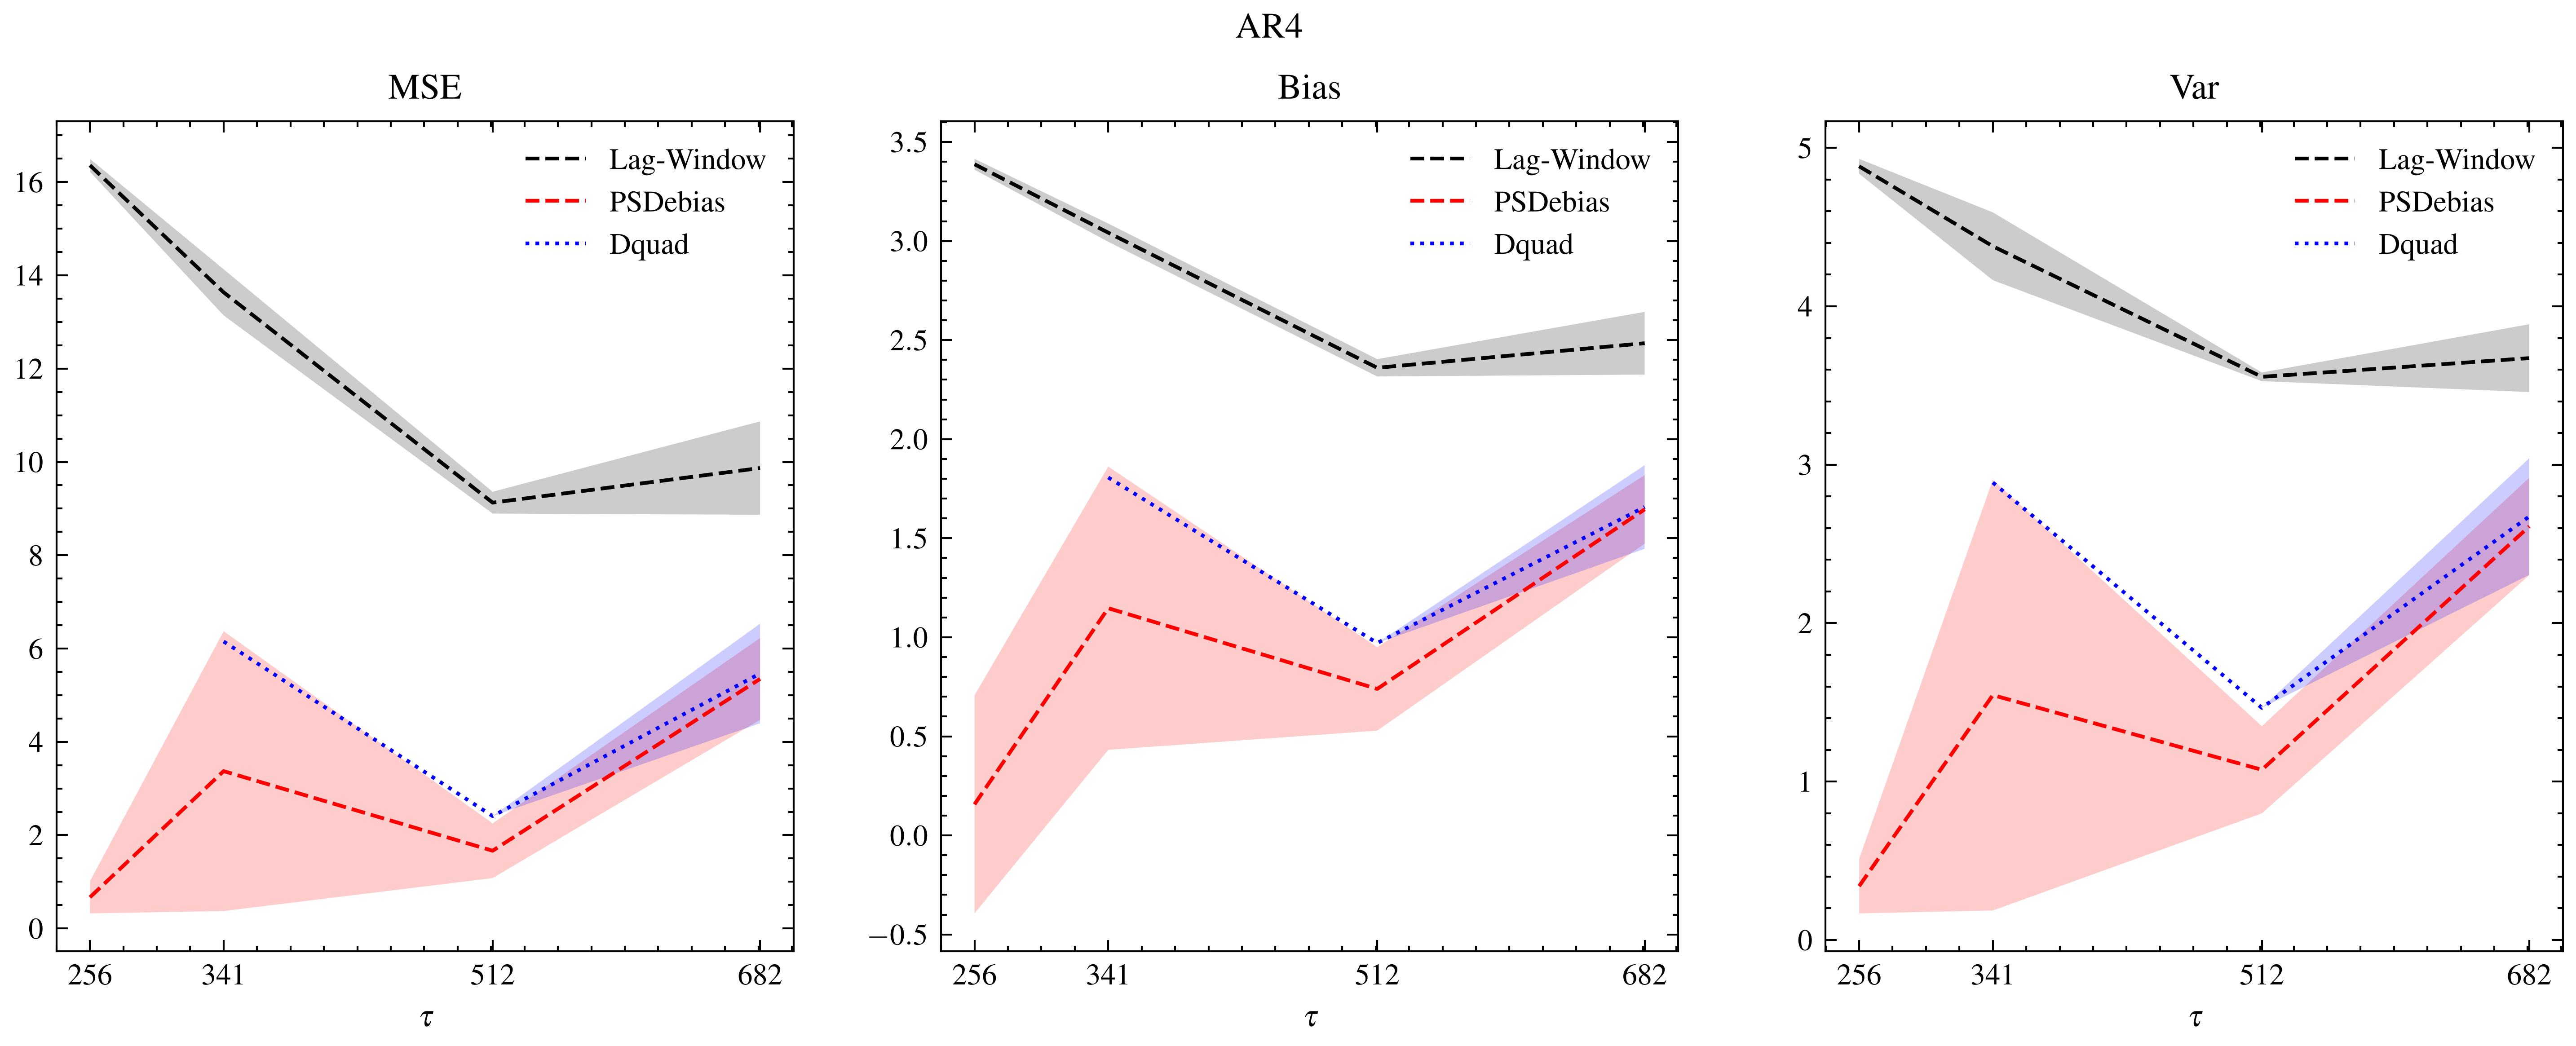

=== Lag-Window / Matérn / debiasing ===
PSDebias:
  256: MSE: 0.25, Bias^2: 0.04, Var: 0.82
  341: MSE: 0.33, Bias^2: 0.02, Var: 0.80
  512: MSE: 0.39, Bias^2: 0.02, Var: 0.64
  682: MSE: 0.42, Bias^2: 0.09, Var: 0.52
Dquad:
  256: MSE: nan, Bias^2: nan, Var: nan
  341: MSE: 0.37, Bias^2: 0.02, Var: 0.89
  512: MSE: 0.52, Bias^2: 0.02, Var: 0.86
  682: MSE: 0.63, Bias^2: 0.05, Var: 0.82


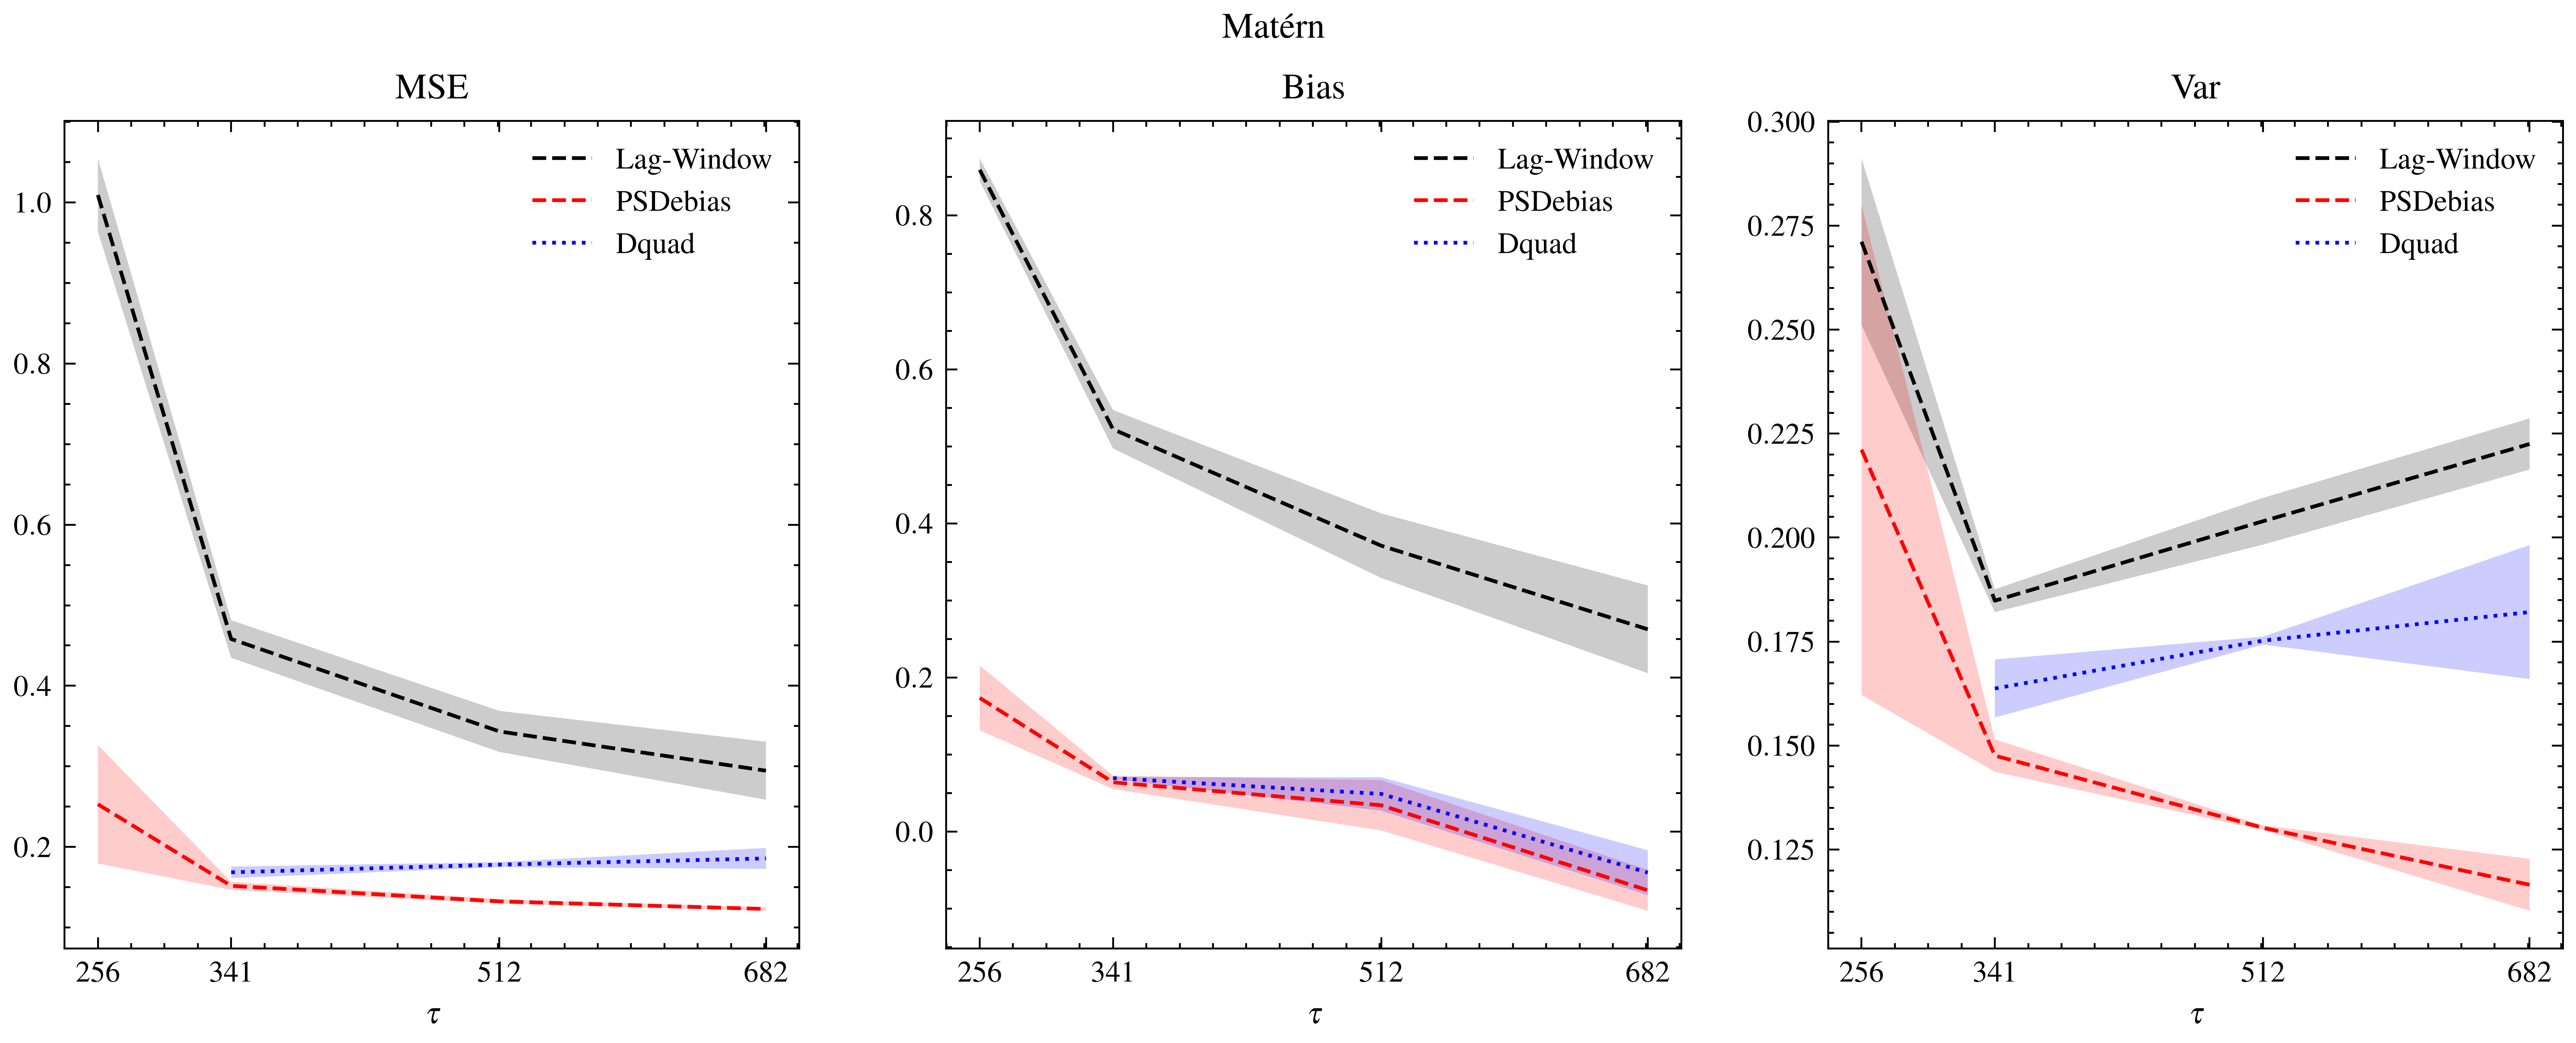

=== Multitaper / AR4 / unbiased ===
PSDebias:
  3: MSE: 0.90, Bias^2: 1.00, Var: 0.84
  4: MSE: 0.93, Bias^2: 1.00, Var: 0.89
  5: MSE: 0.95, Bias^2: 1.00, Var: 0.91
  6: MSE: 0.96, Bias^2: 1.00, Var: 0.93
Wavelet Thresholding:
  3: MSE: 0.91, Bias^2: 1.00, Var: 0.86
  4: MSE: 0.94, Bias^2: 1.00, Var: 0.89
  5: MSE: 0.95, Bias^2: 1.00, Var: 0.91
  6: MSE: 0.96, Bias^2: 1.00, Var: 0.93


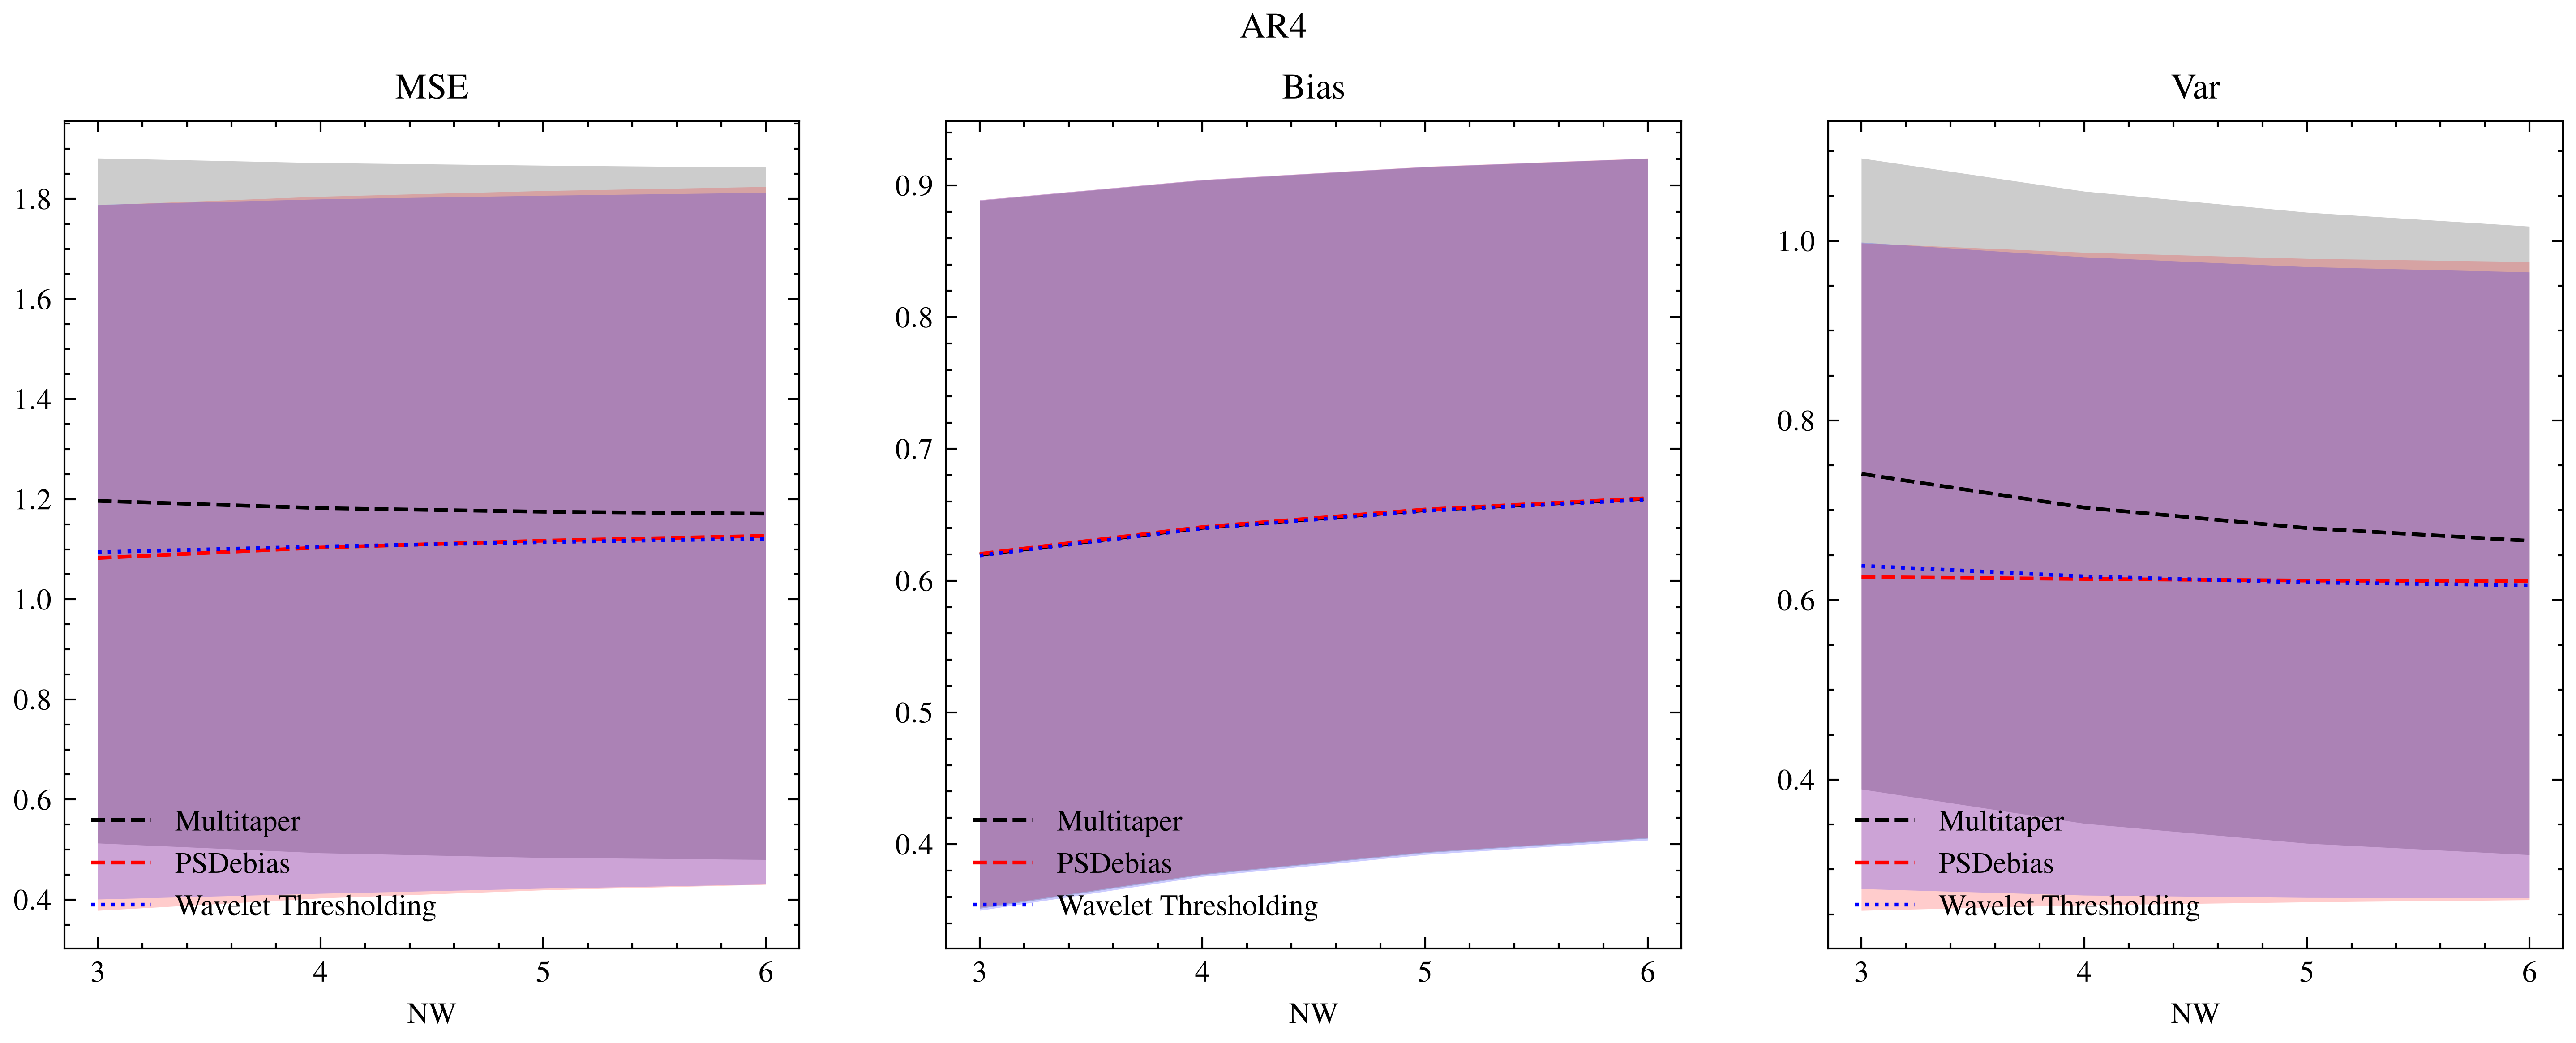

=== Multitaper / Matérn / unbiased ===
PSDebias:
  3: MSE: 0.27, Bias^2: 1.03, Var: 0.25
  4: MSE: 0.41, Bias^2: 1.03, Var: 0.38
  5: MSE: 0.51, Bias^2: 1.02, Var: 0.46
  6: MSE: 0.57, Bias^2: 1.02, Var: 0.52
Wavelet Thresholding:
  3: MSE: 0.28, Bias^2: 1.28, Var: 0.25
  4: MSE: 0.34, Bias^2: 1.19, Var: 0.29
  5: MSE: 0.40, Bias^2: 1.14, Var: 0.33
  6: MSE: 0.45, Bias^2: 1.12, Var: 0.38


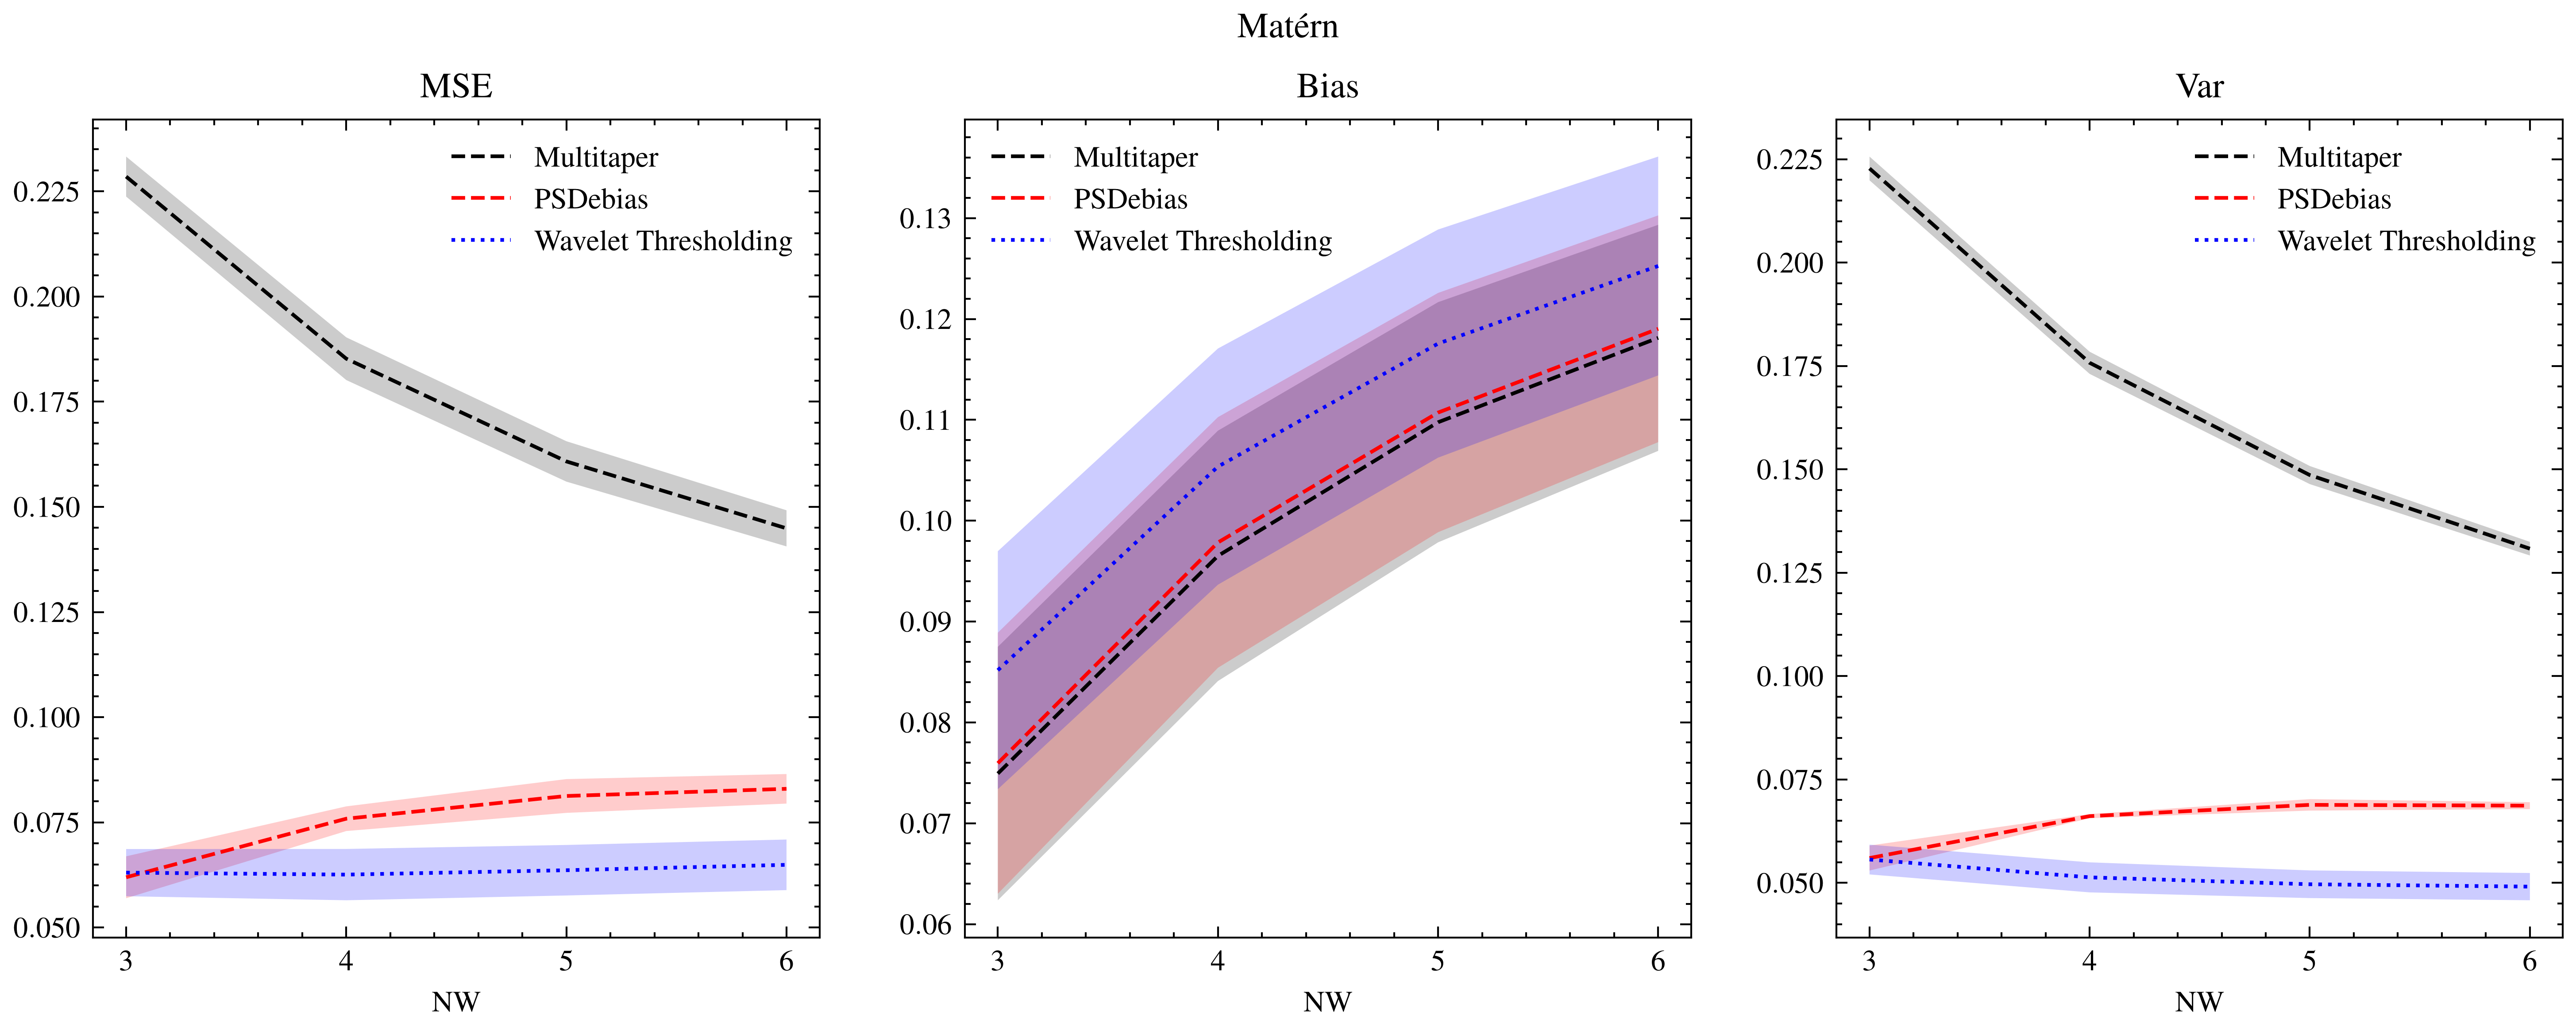

=== Multitaper / AR4 / debiasing ===
PSDebias:
  3: MSE: 0.38, Bias^2: 0.27, Var: 0.53
  4: MSE: 0.44, Bias^2: 0.30, Var: 0.60
  6: MSE: 0.62, Bias^2: 0.48, Var: 0.77
  8: MSE: 0.23, Bias^2: 0.12, Var: 0.35
Dquad:
  3: MSE: 0.65, Bias^2: 0.47, Var: 0.88
  4: MSE: nan, Bias^2: nan, Var: nan
  6: MSE: nan, Bias^2: nan, Var: nan
  8: MSE: nan, Bias^2: nan, Var: nan


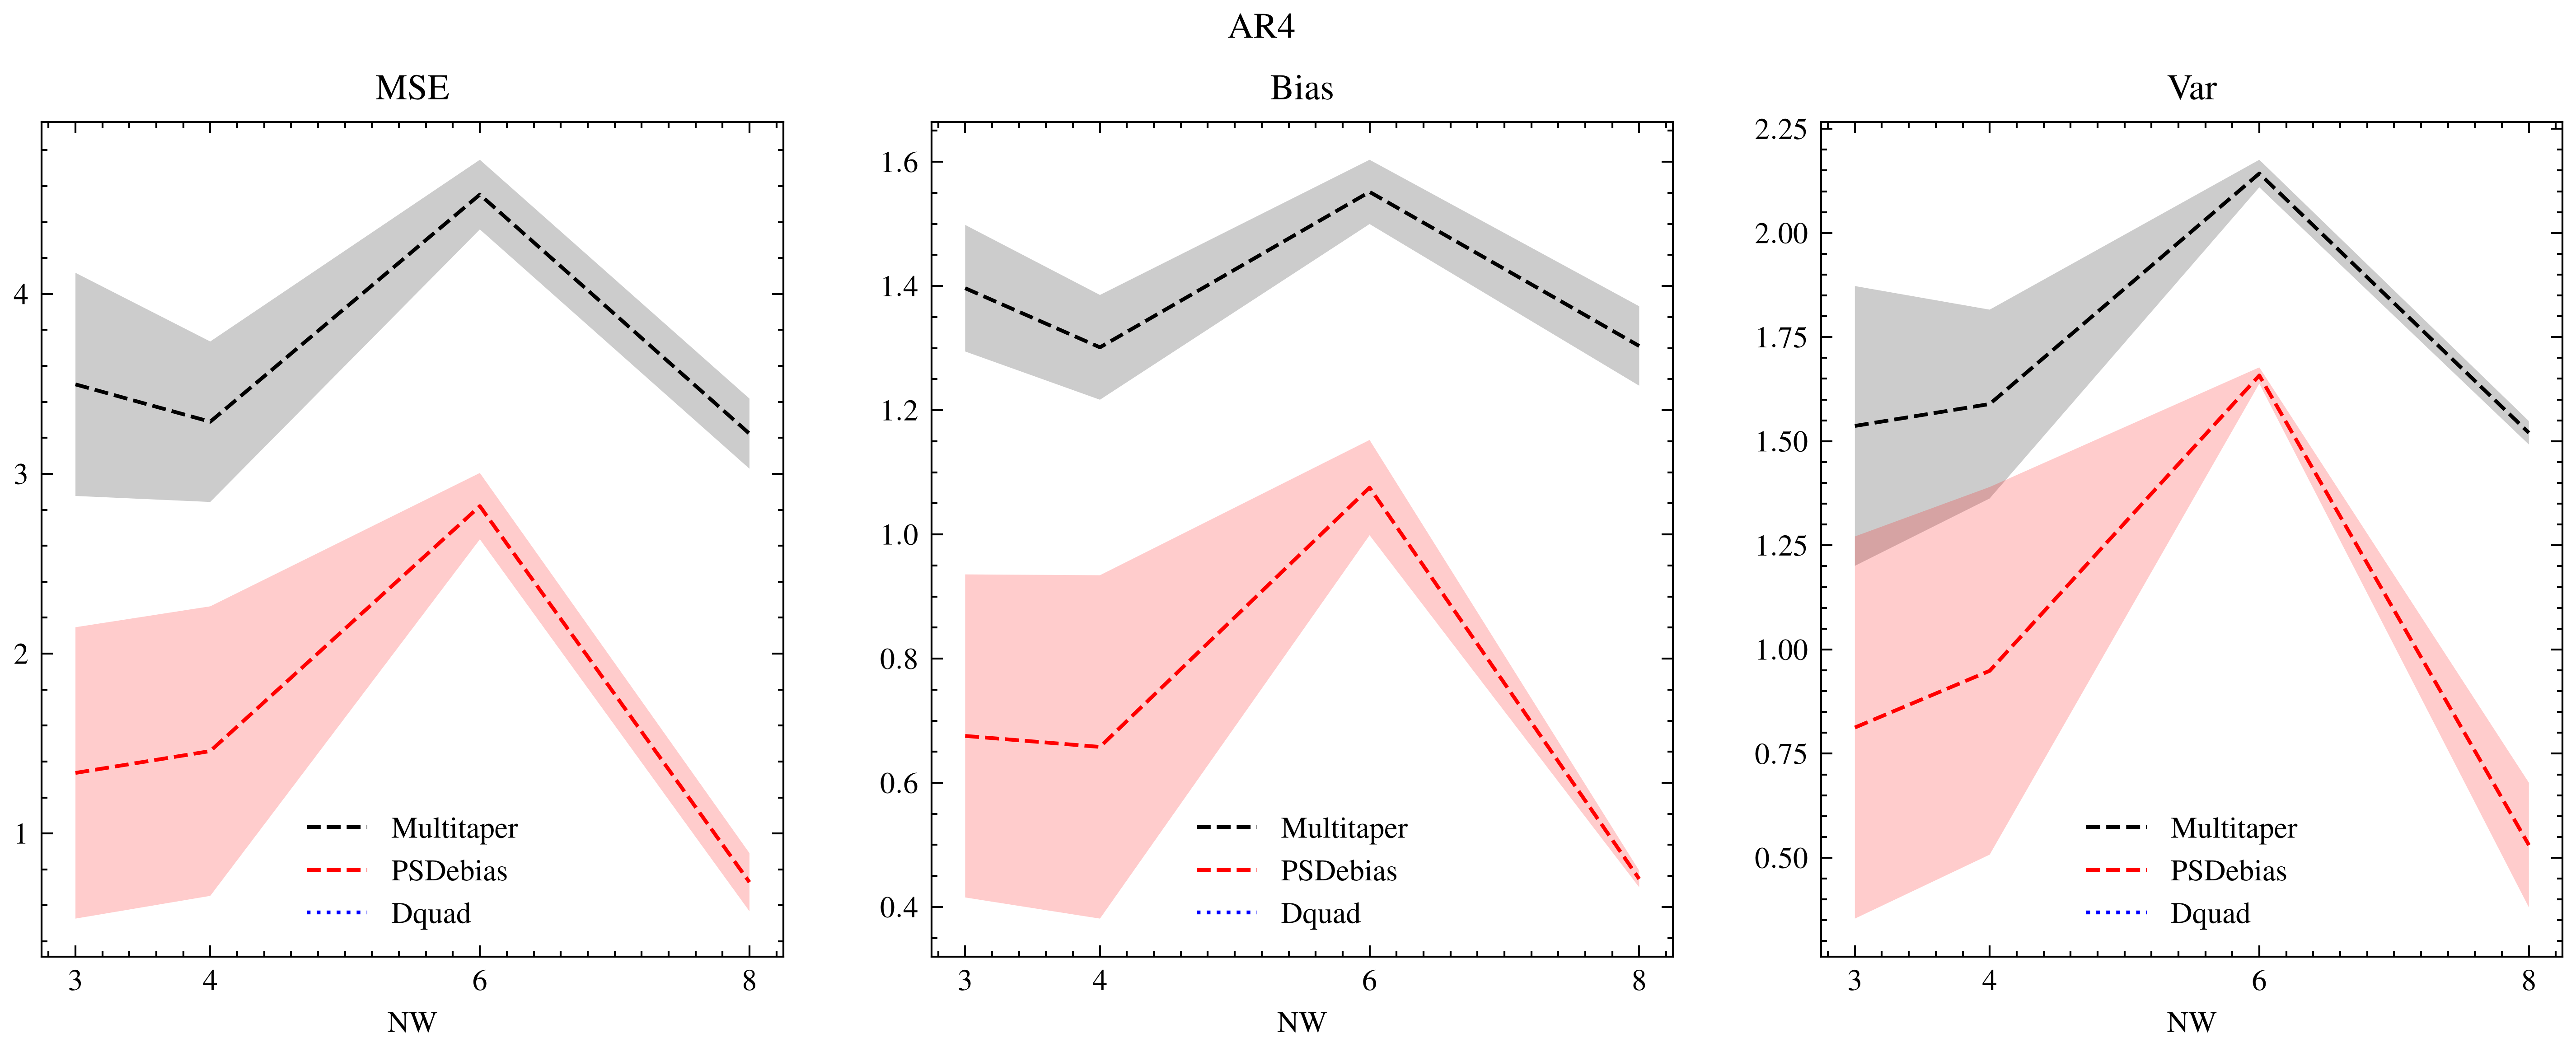

=== Multitaper / Matérn / debiasing ===
PSDebias:
  3: MSE: 0.90, Bias^2: 1.64, Var: 0.87
  4: MSE: 0.89, Bias^2: 0.10, Var: 0.99
  6: MSE: 1.58, Bias^2: 0.13, Var: 1.84
  8: MSE: 1.40, Bias^2: 0.22, Var: 1.62
Dquad:
  3: MSE: 1.05, Bias^2: 1.36, Var: 1.03
  4: MSE: 1.22, Bias^2: 0.11, Var: 1.37
  6: MSE: 2.11, Bias^2: 0.13, Var: 2.47
  8: MSE: nan, Bias^2: nan, Var: nan


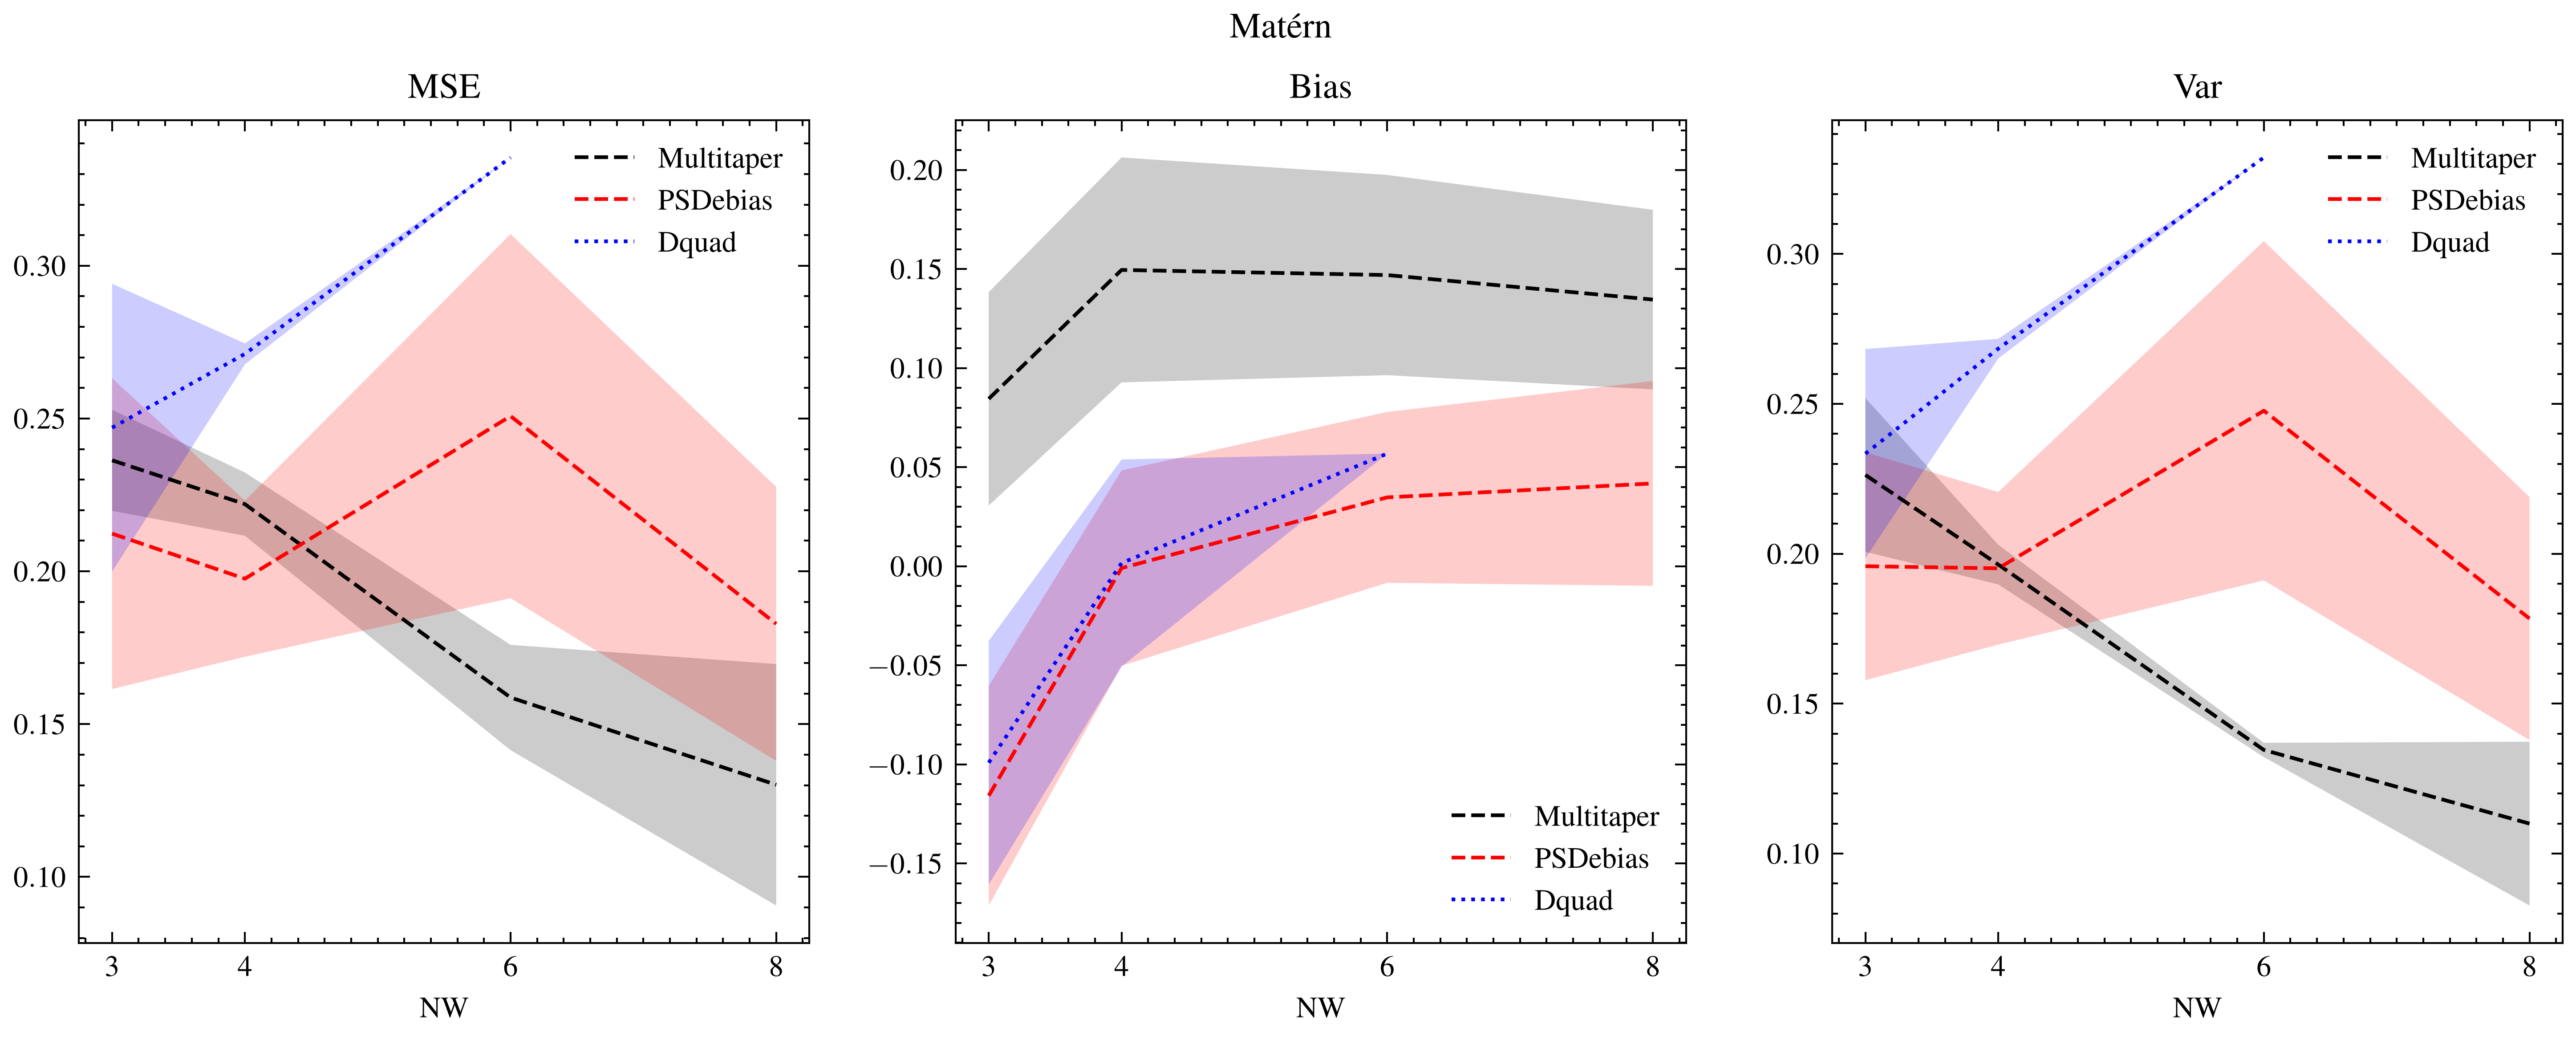

In [20]:
os.makedirs(f'{FIGS}/results', exist_ok=True)
results_store = {}

for method_name, cfg in METHODS.items():
    for arm, arm_slug in ARMS.items():
        for signal, scfg in SIGNALS.items():
            base_dir = f"{BASE}/{signal}_{arm}"
            if not os.path.isdir(f"{base_dir}/{cfg['sim_subdir']}"):
                continue
            file_ms = cfg['file_ms'][arm]
            display_ms = cfg['display_ms'][arm]

            results = load_results(cfg, file_ms, base_dir, signal)
            stats = compute_stats(results)
            results_store[(method_name, arm, signal)] = (results, stats)

            print(f"=== {method_name} / {scfg['title']} / {arm} ===")
            print_ratios(stats, display_ms)

            fig, ax = plot_results(display_ms, stats, label=method_name,
                                   xlabel=cfg['xlabel'],
                                   xticklabels=cfg['xticklabels'],
                                   fig_title=scfg['title'])
            fig.savefig(f"{FIGS}/results/{cfg['slug']}_{scfg['slug']}_{arm_slug}.pdf",
                        bbox_inches='tight')
            plt.show()
            plt.close(fig)

## Average rank across simulations

Hand-recorded average ranks from the paper's write-up (not derived from the
arrays above).

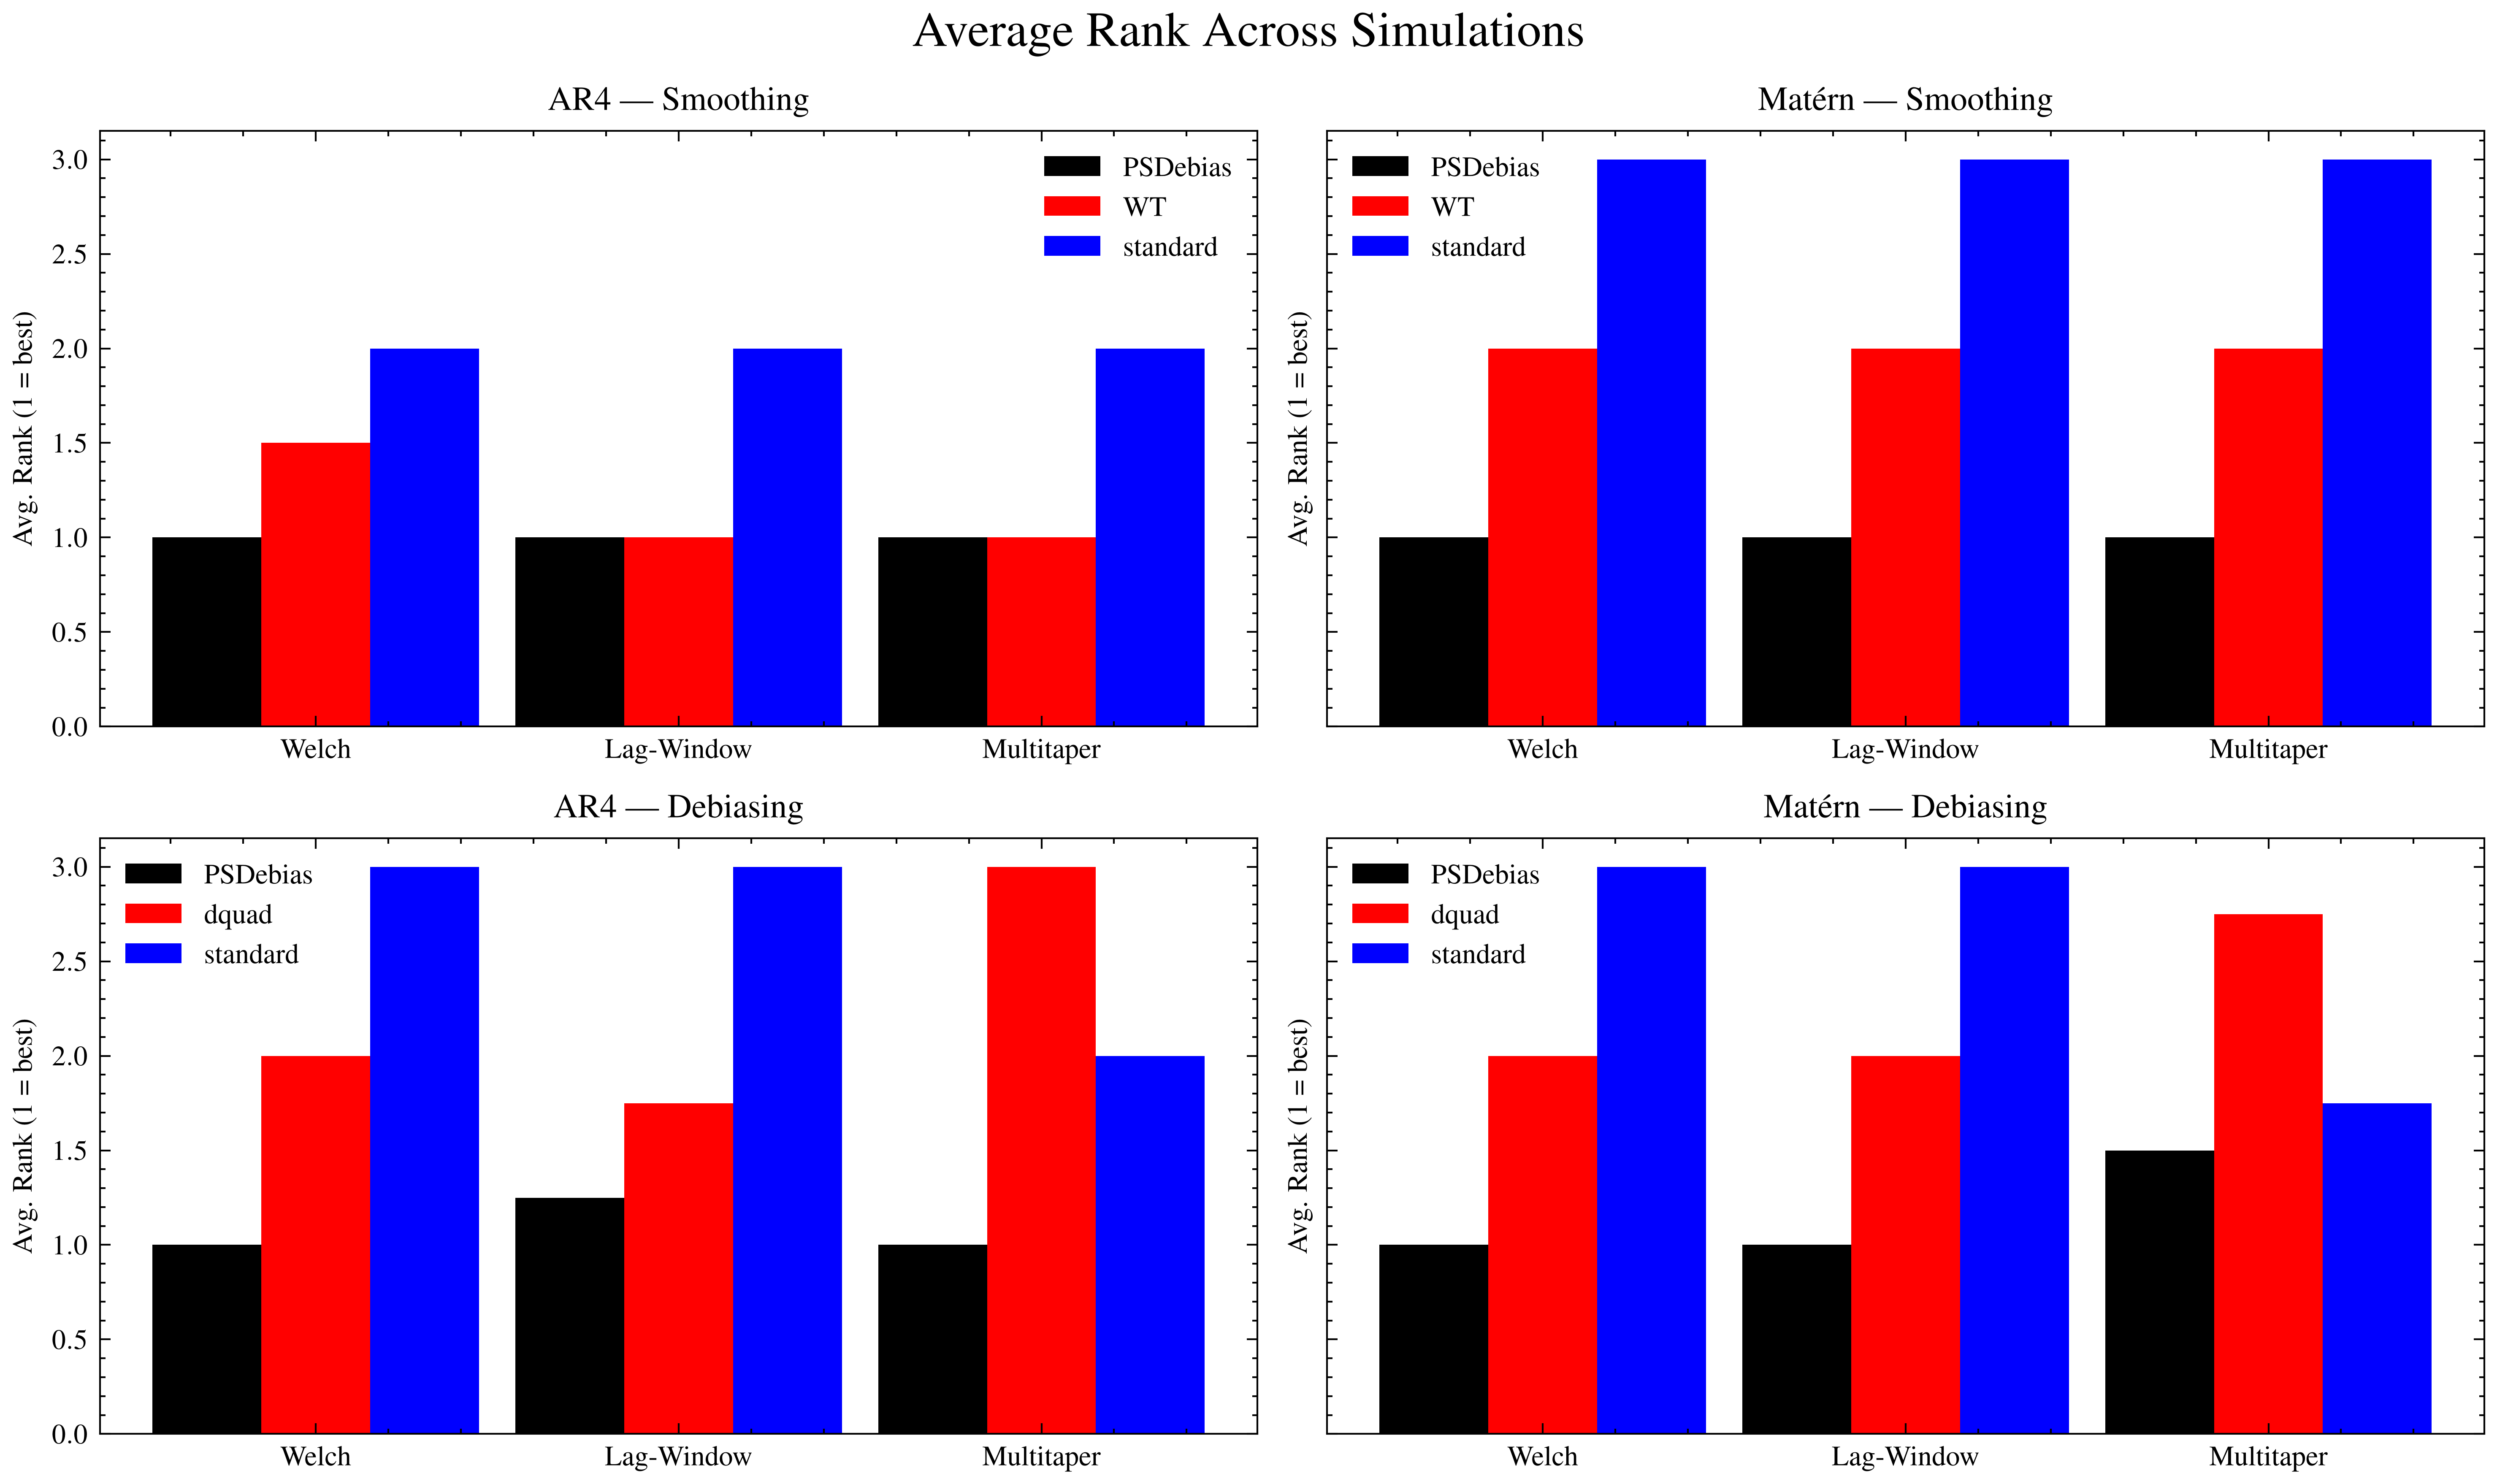

In [21]:
Experiments_Smoothing = {
    'AR4': {
        'Welch': {'PSDebias': 1, 'WT': 1.5, 'standard': 2},
        'Lag-Window': {'PSDebias': 1, 'WT': 1, 'standard': 2},
        'Multitaper': {'PSDebias': 1, 'WT': 1, 'standard': 2},
    },
    'Matérn': {
        'Welch': {'PSDebias': 1, 'WT': 2, 'standard': 3},
        'Lag-Window': {'PSDebias': 1, 'WT': 2, 'standard': 3},
        'Multitaper': {'PSDebias': 1, 'WT': 2, 'standard': 3},
    },
}
Experiments_Debiasing = {
    'AR4': {
        'Welch': {'PSDebias': 1, 'dquad': 2, 'standard': 3},
        'Lag-Window': {'PSDebias': 1.25, 'dquad': 1.75, 'standard': 3},
        'Multitaper': {'PSDebias': 1, 'dquad': 3, 'standard': 2},
    },
    'Matérn': {
        'Welch': {'PSDebias': 1, 'dquad': 2, 'standard': 3},
        'Lag-Window': {'PSDebias': 1, 'dquad': 2, 'standard': 3},
        'Multitaper': {'PSDebias': 1.5, 'dquad': 2.75, 'standard': 1.75},
    },
}


def _plot_bars(ax, data, title):
    estimators = list(data.keys())
    all_methods = list(dict.fromkeys(m for est in data.values() for m in est))

    x = np.arange(len(estimators))
    n = len(all_methods)
    width = 0.9 / n

    for i, method in enumerate(all_methods):
        offsets = (i - n / 2 + 0.5) * width
        vals = [data[est].get(method, np.nan) for est in estimators]
        ax.bar(x + offsets, vals, width, label=method)

    ax.set_xticks(x)
    ax.set_xticklabels(estimators)
    ax.set_ylabel('Avg. Rank (1 = best)')
    ax.set_title(title)
    ax.legend()
    ax.invert_yaxis()


fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey=True)
fig.suptitle('Average Rank Across Simulations', fontsize=14)

for row, (exp_name, exp_dict) in enumerate([
    ('Smoothing', Experiments_Smoothing),
    ('Debiasing', Experiments_Debiasing),
]):
    for col, data_type in enumerate(['AR4', 'Matérn']):
        _plot_bars(axes[row, col], exp_dict[data_type], f'{data_type} — {exp_name}')

plt.tight_layout()
fig.savefig(f'{FIGS}/bar_results.pdf', bbox_inches='tight')